# Fine-Tuning Social-STGCNN — Specialized Training Tradeoff Sweep (zara2)

**Goal:** Map out the trade-off curve at larger d_min (1.0, 2.0 m) and λ (5, 10) to
characterize the operating regime of collision-focused specialized training.

Sweeps: `LOSS_FN_LIST = [hinge, exp, gauss, ecp]`, `D_MIN_LIST = [1.0, 2.0]`, `LAMBDA_LIST = [5, 10]`.

**Note:** d_min=1.0–2.0 m is well above the natural pedestrian separation in zara2;
expect significant ADE/FDE degradation at λ=10. Outputs go to `./finetune_specialized2_zara2/`.


## 1. Environment setup

In [1]:
!nvidia-smi
import torch
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available(),
      '-', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU')

Fri May  1 16:11:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   46C    P8             12W /  220W |    2068MiB /  12282MiB |     10%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%pip install -q networkx tqdm pandas

Note: you may need to restart the kernel to use updated packages.


## 2. Mount Google Drive & set project directory

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

# import os
# PROJECT_DIR = '/content/drive/MyDrive/DLproject-Social-STGCNN'
# assert os.path.isdir(PROJECT_DIR), f'Project not found at {PROJECT_DIR}'
# os.chdir(PROJECT_DIR)
# print('CWD:', os.getcwd() 

In [4]:
# Option C: Local machine
import os
PROJECT_DIR = r'D:\OMSCS\DLproject-Social-STGCNN'
assert os.path.isdir(PROJECT_DIR), f'Repo not found at {PROJECT_DIR}'
os.chdir(PROJECT_DIR)
print('Working directory:', os.getcwd())
print('Files:', [f for f in os.listdir('.') if not f.startswith('.')])

Working directory: D:\OMSCS\DLproject-Social-STGCNN
Files: ['architecture_diagram.pdf', 'architecture_diagram.png', 'baseline', 'baseline_results.csv', 'checkpoint', 'Colab_Baseline_Eval.ipynb', 'Colab_Collision1_hinge_Eval.ipynb', 'Colab_Collision2_exp_Eval.ipynb', 'Colab_Collision3_inv_Eval.ipynb', 'Colab_Collision4_gauss_Eval.ipynb', 'Colab_Collision5_ecp_Eval.ipynb', 'Colab_FineTune_zara2_ecp.ipynb', 'Colab_FineTune_zara2_otherloss.ipynb', 'Colab_FineTune_zara2_specialized.ipynb', 'Colab_FineTune_zara2_specialized2_tune.ipynb', 'Colab_Train.ipynb', 'Collision_Aware_Trajectory_Prediction_Plan.md', 'collision_losses.py', 'datasets', 'ecp_d_02_lambda_1', 'exp_d_02_lambda_1', 'finetune_ecp', 'finetune_other_losses_zara2_labda5_dmin0205', 'finetune_specialized_zara2', 'gauss_d_02_lambda_1', 'hinge_d_02_lambda_1', 'images', 'inv_d_02_lambda_1', 'LICENSE', 'metrics.py', 'mock_collision_demo.png', 'mock_collision_demo.py', 'model.py', 'README.MD', 'record.txt', 'requirements.txt', 'results

## 3. Imports

In [5]:
import os, copy, pickle, math, glob
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torch.optim as optim
import torch.distributions.multivariate_normal as torchdist
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from model import social_stgcnn
from utils import TrajectoryDataset
from metrics import ade, fde, collision_metrics, seq_to_nodes, nodes_rel_to_nodes_abs
from collision_losses import collision_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 4. Experiment configuration

In [6]:
# ── Fixed settings ────────────────────────────────────────────────────────
DATASET         = 'zara2'
ECP_K           = 10
BASELINE_CKPT   = './baseline/social-stgcnn-zara2/val_best.pth'
BASELINE_ARGS   = './baseline/social-stgcnn-zara2/args.pkl'
FINETUNE_ROOT   = './finetune_specialized2_zara2'
FINETUNE_LR     = 0.001
BATCH_SIZE      = 128
KSTEPS          = 20
D_COL_EVAL      = 0.2   # evaluation collision radius

# ── Specialized training settings ──────────────────────────────────────────
SPECIALIZED_EPOCHS     = 50
SPECIALIZED_BATCH_SIZE = 16    # used in training loop (filtered loader); BATCH_SIZE is only used in validation
SPECIALIZED_BUFFER = 2.0   # filter: include scenes with pairs within BUFFER*d_min
SPECIALIZED_TAG    = 'spec'

# ── Sweep grid ─────────────────────────────────────────────────────────────
LOSS_FN_LIST = ['hinge', 'exp', 'gauss', 'ecp']
D_MIN_LIST   = [1.0, 2.0]
LAMBDA_LIST  = [5, 10]

CONFIGS = [
    {'loss_fn': loss, 'd_min': d, 'lambda_col': l}
    for loss in LOSS_FN_LIST
    for d in D_MIN_LIST
    for l in LAMBDA_LIST
]

def run_tag(cfg):
    return f'social-stgcnn-{DATASET}-{cfg["loss_fn"]}-dmin{cfg["d_min"]}-lam{cfg["lambda_col"]}-{SPECIALIZED_TAG}'

def run_dir(cfg):
    return os.path.join(FINETUNE_ROOT, run_tag(cfg))

os.makedirs(FINETUNE_ROOT, exist_ok=True)
print(f'Fine-tuning {len(CONFIGS)} configs on {DATASET} (specialized, {SPECIALIZED_EPOCHS} epochs):')
for c in CONFIGS:
    print(f'  loss={c["loss_fn"]}  d_min={c["d_min"]}  lambda_col={c["lambda_col"]}  ->  {run_dir(c)}')


Fine-tuning 16 configs on zara2 (specialized, 50 epochs):
  loss=hinge  d_min=1.0  lambda_col=5  ->  ./finetune_specialized2_zara2\social-stgcnn-zara2-hinge-dmin1.0-lam5-spec
  loss=hinge  d_min=1.0  lambda_col=10  ->  ./finetune_specialized2_zara2\social-stgcnn-zara2-hinge-dmin1.0-lam10-spec
  loss=hinge  d_min=2.0  lambda_col=5  ->  ./finetune_specialized2_zara2\social-stgcnn-zara2-hinge-dmin2.0-lam5-spec
  loss=hinge  d_min=2.0  lambda_col=10  ->  ./finetune_specialized2_zara2\social-stgcnn-zara2-hinge-dmin2.0-lam10-spec
  loss=exp  d_min=1.0  lambda_col=5  ->  ./finetune_specialized2_zara2\social-stgcnn-zara2-exp-dmin1.0-lam5-spec
  loss=exp  d_min=1.0  lambda_col=10  ->  ./finetune_specialized2_zara2\social-stgcnn-zara2-exp-dmin1.0-lam10-spec
  loss=exp  d_min=2.0  lambda_col=5  ->  ./finetune_specialized2_zara2\social-stgcnn-zara2-exp-dmin2.0-lam5-spec
  loss=exp  d_min=2.0  lambda_col=10  ->  ./finetune_specialized2_zara2\social-stgcnn-zara2-exp-dmin2.0-lam10-spec
  loss=gauss  

## 5. Load shared data loaders

Also verifies how many training pairs fall within each `d_min` threshold — this confirms
the collision loss will actually fire during training.

In [7]:
data_root = f'./datasets/{DATASET}/'

with open(BASELINE_ARGS, 'rb') as f:
    base_args = pickle.load(f)

obs_len  = base_args.obs_seq_len   # 8
pred_len = base_args.pred_seq_len  # 12

print("obs_len:", obs_len)
print("pred_len:", pred_len)

print('Building datasets ...', flush=True)
dset_train = TrajectoryDataset(data_root+'train/', obs_len=obs_len, pred_len=pred_len,
                               skip=1, norm_lap_matr=True)
dset_val   = TrajectoryDataset(data_root+'val/',   obs_len=obs_len, pred_len=pred_len,
                               skip=1, norm_lap_matr=True)
dset_test  = TrajectoryDataset(data_root+'test/',  obs_len=obs_len, pred_len=pred_len,
                               skip=1, norm_lap_matr=True)

loader_train = DataLoader(dset_train, batch_size=1, shuffle=True,  num_workers=0)
loader_val   = DataLoader(dset_val,   batch_size=1, shuffle=False, num_workers=0)
loader_test  = DataLoader(dset_test,  batch_size=1, shuffle=False, num_workers=0)

print(f'Train: {len(dset_train)}  Val: {len(dset_val)}  Test: {len(dset_test)} scenes')

# How many training pairs fall inside each d_min? — confirms the loss will fire
print('\nPairwise distance coverage in training data:')
all_dists = []
for path in glob.glob(data_root + 'train/*.txt'):
    raw = np.loadtxt(path)
    for fr in np.unique(raw[:, 0]):
        xy = raw[raw[:, 0] == fr][:, 2:]
        N = len(xy)
        for i in range(N):
            for j in range(i+1, N):
                all_dists.append(np.linalg.norm(xy[i] - xy[j]))
all_dists = np.array(all_dists)
print(f'  Total ped pairs : {len(all_dists):,}')
for thr in [0.2, 0.5, 1.0]:
    n = (all_dists < thr).sum()
    print(f'  Pairs < {thr} m  : {n:5d}  ({100*n/len(all_dists):.3f}%)')

obs_len: 8
pred_len: 12
Building datasets ...
Processing Data ..... (2112/2112)
Processing Data ..... (501/501)
Processing Data ..... (921/921)
Train: 2112  Val: 501  Test: 921 scenes

Pairwise distance coverage in training data:
  Total ped pairs : 823,220
  Pairs < 0.2 m  :    64  (0.008%)
  Pairs < 0.5 m  :  5108  (0.620%)
  Pairs < 1.0 m  : 29278  (3.557%)


## 6. Collision-scene filter

`build_collision_loader` scans every training scene and keeps only those where
at least one pedestrian pair in the **prediction ground truth** comes within
`SPECIALIZED_BUFFER × d_min`. These are the scenes where the collision loss
actually fires a non-zero gradient.


In [8]:
from torch.utils.data import Subset

def build_collision_loader(dataset, d_min, buffer=SPECIALIZED_BUFFER, shuffle=True):
    threshold = buffer * d_min
    collision_indices = []
    tmp = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
    for idx, batch in enumerate(tmp):
        pos = batch[1][0].permute(2, 0, 1)   # pred_traj (1,N,2,T) -> (T,N,2)
        N = pos.shape[1]
        if N < 2:
            continue
        iu = torch.triu_indices(N, N, offset=1)
        found = False
        for t in range(pos.shape[0]):
            if torch.norm(pos[t, iu[0]] - pos[t, iu[1]], dim=-1).min().item() < threshold:
                found = True
                break
        if found:
            collision_indices.append(idx)
    pct = 100 * len(collision_indices) / max(len(dataset), 1)
    print(f'  d_min={d_min}  buffer={buffer}  ->  {len(collision_indices)}/{len(dataset)} scenes ({pct:.1f}%)')
    return DataLoader(Subset(dataset, collision_indices), batch_size=1,
                      shuffle=shuffle, num_workers=0)

print('Building collision-filtered loaders...')
collision_loaders = {
    d: build_collision_loader(dset_train, d_min=d)
    for d in D_MIN_LIST
}
print('Done.')


Building collision-filtered loaders...
  d_min=1.0  buffer=2.0  ->  1954/2112 scenes (92.5%)
  d_min=2.0  buffer=2.0  ->  2050/2112 scenes (97.1%)
Done.


## 7. Model builder


In [9]:
def build_model_from_baseline():
    m = social_stgcnn(
        n_stgcnn    = base_args.n_stgcnn,
        n_txpcnn    = base_args.n_txpcnn,
        output_feat = base_args.output_size,
        seq_len     = base_args.obs_seq_len,
        kernel_size = base_args.kernel_size,
        pred_seq_len= base_args.pred_seq_len,
    ).to(device)
    m.load_state_dict(torch.load(BASELINE_CKPT, map_location=device))
    return m

_m = build_model_from_baseline()
print(f'Model parameters: {sum(p.numel() for p in _m.parameters()):,}')
del _m

Model parameters: 7,668


## 8. Specialized fine-tuning function

Same as the standard `fine_tune()` but:
- Takes a `loader` argument (the collision-filtered DataLoader)
- Takes an `epochs` argument (defaults to `SPECIALIZED_EPOCHS=50`)
- Checkpoints saved under `FINETUNE_ROOT` with `_spec` suffix in the tag


In [10]:
from IPython.display import clear_output

def bivariate_loss(V_pred, V_trgt):
    normx = V_trgt[:,:,0] - V_pred[:,:,0]
    normy = V_trgt[:,:,1] - V_pred[:,:,1]
    sx    = torch.exp(V_pred[:,:,2])
    sy    = torch.exp(V_pred[:,:,3])
    corr  = torch.tanh(V_pred[:,:,4])
    sxsy  = sx * sy
    z     = (normx/sx)**2 + (normy/sy)**2 - 2*corr*normx*normy/sxsy
    negRho = 1 - corr**2
    result = torch.exp(-z / (2*negRho))
    denom  = 2 * math.pi * sxsy * torch.sqrt(negRho)
    return -torch.log(torch.clamp(result/denom, min=1e-20)).mean()


def _plot_live(history, best, tag, epoch, total_epochs, loss_fn, save_path=None):
    ep = range(len(history['train_nll']))
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ep, history['train_nll'], label='Train NLL', color='steelblue', linewidth=1.8)
    ax.plot(ep, history['train_col'], label=f'Train {loss_fn} (unscaled)',
            color='darkorange', linewidth=1.8, linestyle='--')
    ax.plot(ep, history['val_loss'],  label='Val NLL', color='crimson', linewidth=1.8, linestyle=':')
    if best['epoch'] >= 0:
        ax.axvline(best['epoch'], color='green', linestyle=':', linewidth=1.2,
                   alpha=0.8, label=f'val_best saved (ep {best["epoch"]})')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss',  fontsize=10)
    ax.set_title(f'{tag}  —  epoch {epoch+1}/{total_epochs}', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches='tight')
    plt.show()


PLOT_EVERY = 10


def fine_tune_specialized(cfg, loader, epochs=SPECIALIZED_EPOCHS, verbose=True):
    loss_fn    = cfg['loss_fn']
    d_min      = cfg['d_min']
    lambda_col = cfg['lambda_col']
    tag        = run_tag(cfg)
    ckpt_dir   = run_dir(cfg)
    os.makedirs(ckpt_dir, exist_ok=True)

    model     = build_model_from_baseline()
    optimizer = optim.SGD(model.parameters(), lr=FINETUNE_LR)

    history = {'train_loss': [], 'train_nll': [], 'train_col': [], 'val_loss': []}
    best    = {'epoch': -1, 'val_loss': float('inf')}

    saved_args = copy.deepcopy(base_args)
    saved_args.collision_loss = loss_fn
    saved_args.lambda_col     = lambda_col
    saved_args.d_min          = d_min
    saved_args.ecp_k          = ECP_K
    with open(os.path.join(ckpt_dir, 'args.pkl'), 'wb') as f:
        pickle.dump(saved_args, f)

    loader_len = len(loader)
    effective_batch_size = min(SPECIALIZED_BATCH_SIZE, loader_len)
    turn_point = int(loader_len/effective_batch_size)*effective_batch_size + loader_len%effective_batch_size - 1

    for epoch in range(epochs):

        # ── Train ─────────────────────────────────────────────────────
        model.train()
        loss_sum = nll_sum = col_sum = 0.0
        n_updates = batch_count = 0
        is_fst = True

        for cnt, batch in enumerate(loader):
            batch_count += 1
            batch = [t.to(device) for t in batch]
            obs_traj, _, _, _, _, _, V_obs, A_obs, V_tr, _ = batch

            optimizer.zero_grad()
            V_pred, _ = model(V_obs.permute(0,3,1,2), A_obs.squeeze())
            V_pred = V_pred.permute(0,2,3,1).squeeze()
            V_tr   = V_tr.squeeze()

            start_pos = obs_traj[0, :, :, -1]
            l_nll = bivariate_loss(V_pred, V_tr)
            col_kwargs = (
                    {'d_min': d_min, 'K': ECP_K} if loss_fn == 'ecp' else
                    {'d_min': d_min}             if loss_fn == 'hinge' else
                    {'alpha': 1.0 / d_min}       if loss_fn == 'exp' else
                    {'sigma': d_min}             if loss_fn == 'gauss' else
                    {}                           # inv: eps is stability only
                )
            l_col = collision_loss(loss_fn, V_pred, start_pos, **col_kwargs)
            l     = l_nll + lambda_col * l_col
            if not torch.isfinite(l):
                print(f'  WARNING: non-finite loss at epoch {epoch} batch {cnt} — skipping run')
                return None

            if batch_count % effective_batch_size != 0 and cnt != turn_point:
                if is_fst: loss_acc = l; nll_acc = l_nll; col_acc = l_col; is_fst = False
                else:       loss_acc += l; nll_acc += l_nll; col_acc += l_col
            else:
                (loss_acc / effective_batch_size).backward()
                optimizer.step()
                loss_sum += (loss_acc / effective_batch_size).item()
                nll_sum  += (nll_acc  / effective_batch_size).item()
                col_sum  += (col_acc  / effective_batch_size).item()
                n_updates += 1
                is_fst = True

        n_updates = max(n_updates, 1)
        history['train_loss'].append(loss_sum / n_updates)
        history['train_nll'].append(nll_sum   / n_updates)
        history['train_col'].append(col_sum   / n_updates)

        # ── Validate (full val set, NLL only) ──────────────────────────
        model.eval()
        vl_sum = vl_acc = 0.0
        v_updates = v_count = 0
        is_fst = True
        vloader_len = len(loader_val)
        v_turn = int(vloader_len/BATCH_SIZE)*BATCH_SIZE + vloader_len%BATCH_SIZE - 1

        with torch.no_grad():
            for cnt, batch in enumerate(loader_val):
                v_count += 1
                batch = [t.to(device) for t in batch]
                _, _, _, _, _, _, V_obs, A_obs, V_tr, _ = batch
                V_pred, _ = model(V_obs.permute(0,3,1,2), A_obs.squeeze())
                V_pred = V_pred.permute(0,2,3,1).squeeze()
                l = bivariate_loss(V_pred, V_tr.squeeze())
                if v_count % BATCH_SIZE != 0 and cnt != v_turn:
                    if is_fst: vl_acc = l; is_fst = False
                    else:       vl_acc += l
                else:
                    vl_sum += (vl_acc / BATCH_SIZE).item()
                    v_updates += 1; is_fst = True

        avg_val = vl_sum / max(v_updates, 1)
        history['val_loss'].append(avg_val)

        if avg_val < best['val_loss']:
            best['val_loss'] = avg_val
            best['epoch']    = epoch
            torch.save(model.state_dict(), os.path.join(ckpt_dir, 'val_best.pth'))

        torch.save(model.state_dict(), os.path.join(ckpt_dir, 'epoch_final.pth'))

        is_last = (epoch == epochs - 1)
        if verbose and (epoch % PLOT_EVERY == 0 or is_last):
            clear_output(wait=True)
            print(f'Run {tag}  [collision scenes={len(loader.dataset)}]')
            print(f'  ep {epoch+1:3d}/{epochs}  '
                  f'nll={history["train_nll"][-1]:.5f}  '
                  f'col={history["train_col"][-1]:.5f}  '
                  f'val={avg_val:.5f}  '
                  f'best_val_ep={best["epoch"]}')
            save_path = os.path.join(ckpt_dir, 'training_curve.png') if is_last else None
            _plot_live(history, best, tag, epoch, epochs, loss_fn, save_path=save_path)

    with open(os.path.join(ckpt_dir, 'metrics.pkl'),          'wb') as f: pickle.dump(history, f)
    with open(os.path.join(ckpt_dir, 'constant_metrics.pkl'), 'wb') as f: pickle.dump(best, f)

    print(f'Saved  val_best (ep {best["epoch"]})  +  epoch_final  ->  {ckpt_dir}')
    return history

print('fine_tune_specialized() defined.  PLOT_EVERY =', PLOT_EVERY)


fine_tune_specialized() defined.  PLOT_EVERY = 10


## 9. Evaluation helper


In [11]:
def evaluate_model(model_path, K=KSTEPS, d_col=D_COL_EVAL):
    """Evaluate a single checkpoint on the zara2 test set."""
    ckpt_dir = os.path.dirname(model_path)
    with open(os.path.join(ckpt_dir, 'args.pkl'), 'rb') as f:
        args = pickle.load(f)

    m = social_stgcnn(
        n_stgcnn=args.n_stgcnn, n_txpcnn=args.n_txpcnn,
        output_feat=args.output_size, seq_len=args.obs_seq_len,
        kernel_size=args.kernel_size, pred_seq_len=args.pred_seq_len,
    ).to(device)
    m.load_state_dict(torch.load(model_path, map_location=device))
    m.eval()

    ade_ls, fde_ls, col_avg_ls, col_minade_ls = [], [], [], []

    with torch.no_grad():
        for batch in loader_test:
            batch = [t.to(device) for t in batch]
            obs_traj, _, obs_traj_rel, _, _, _, V_obs, A_obs, V_tr, _ = batch
            num_objs = obs_traj_rel.shape[1]

            V_pred, _ = m(V_obs.permute(0,3,1,2), A_obs.squeeze())
            V_pred = V_pred.permute(0,2,3,1).squeeze()[:, :num_objs, :]
            V_tr   = V_tr.squeeze()[:, :num_objs, :]

            sx   = torch.exp(V_pred[:,:,2])
            sy   = torch.exp(V_pred[:,:,3])
            corr = torch.tanh(V_pred[:,:,4])
            cov  = torch.zeros(*V_pred.shape[:2], 2, 2, device=device)
            cov[:,:,0,0] = sx*sx; cov[:,:,0,1] = corr*sx*sy
            cov[:,:,1,0] = corr*sx*sy; cov[:,:,1,1] = sy*sy
            mvn = torchdist.MultivariateNormal(V_pred[:,:,:2], cov)

            V_x     = seq_to_nodes(obs_traj.cpu().numpy().copy())
            V_x_abs = nodes_rel_to_nodes_abs(
                V_obs.cpu().numpy().squeeze().copy(), V_x[0].copy())
            V_y_abs = nodes_rel_to_nodes_abs(
                V_tr.cpu().numpy().squeeze().copy(), V_x[-1].copy())

            ade_pp = {n: [] for n in range(num_objs)}
            fde_pp = {n: [] for n in range(num_objs)}
            samples_scene = []

            for _ in range(K):
                samp_abs = nodes_rel_to_nodes_abs(
                    mvn.sample().cpu().numpy().squeeze().copy(), V_x[-1].copy())
                samples_scene.append(samp_abs[:, :num_objs, :])
                for n in range(num_objs):
                    ade_pp[n].append(ade([samp_abs[:,n:n+1,:]], [V_y_abs[:,n:n+1,:]], [1]))
                    fde_pp[n].append(fde([samp_abs[:,n:n+1,:]], [V_y_abs[:,n:n+1,:]], [1]))

            for n in range(num_objs):
                ade_ls.append(min(ade_pp[n]))
                fde_ls.append(min(fde_pp[n]))

            col = collision_metrics(samples_scene, V_y_abs[:,:num_objs,:], d_col=d_col)
            col_avg_ls.append(col['ColRate_avg'])
            col_minade_ls.append(col['ColRate_minADE'])

    return {
        'ADE':            sum(ade_ls)        / len(ade_ls),
        'FDE':            sum(fde_ls)        / len(fde_ls),
        'ColRate_avg':    sum(col_avg_ls)    / len(col_avg_ls),
        'ColRate_minADE': sum(col_minade_ls) / len(col_minade_ls),
    }

print('evaluate_model() defined.')

evaluate_model() defined.


## 10. Run specialized fine-tuning

5 loss functions x 2 d_min x 2 lambda = **20 configs** x ~5-10 min each on T4 (fewer epochs + smaller dataset).  Estimated total: **~2.5 hr**.


Run social-stgcnn-zara2-ecp-dmin2.0-lam10-spec  [collision scenes=2050]
  ep  50/50  nll=-0.95657  col=0.06500  val=-0.85025  best_val_ep=36


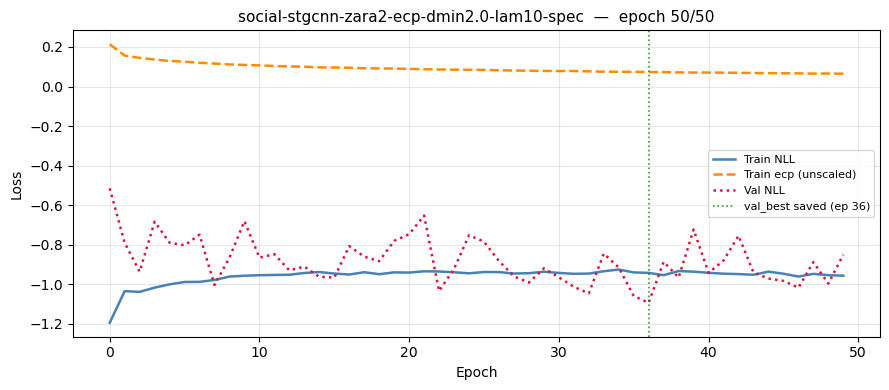

Saved  val_best (ep 36)  +  epoch_final  ->  ./finetune_specialized2_zara2\social-stgcnn-zara2-ecp-dmin2.0-lam10-spec

All specialized fine-tuning runs complete.


In [12]:
all_histories = {}

for i, cfg in enumerate(CONFIGS):
    col_loader = collision_loaders[cfg['d_min']]
    sep = '='*60
    print(f'\n{sep}')
    print(f'Config {i+1}/{len(CONFIGS)}: loss={cfg["loss_fn"]}  d_min={cfg["d_min"]}  '
          f'lambda_col={cfg["lambda_col"]}  collision_scenes={len(col_loader.dataset)}')
    print(sep)
    hist = fine_tune_specialized(cfg, col_loader, epochs=SPECIALIZED_EPOCHS)
    if hist is None:
        print(f'  Skipped {run_tag(cfg)} due to divergence.')
    else:
        all_histories[run_tag(cfg)] = hist

print('\nAll specialized fine-tuning runs complete.')


## 11. Training curve summary


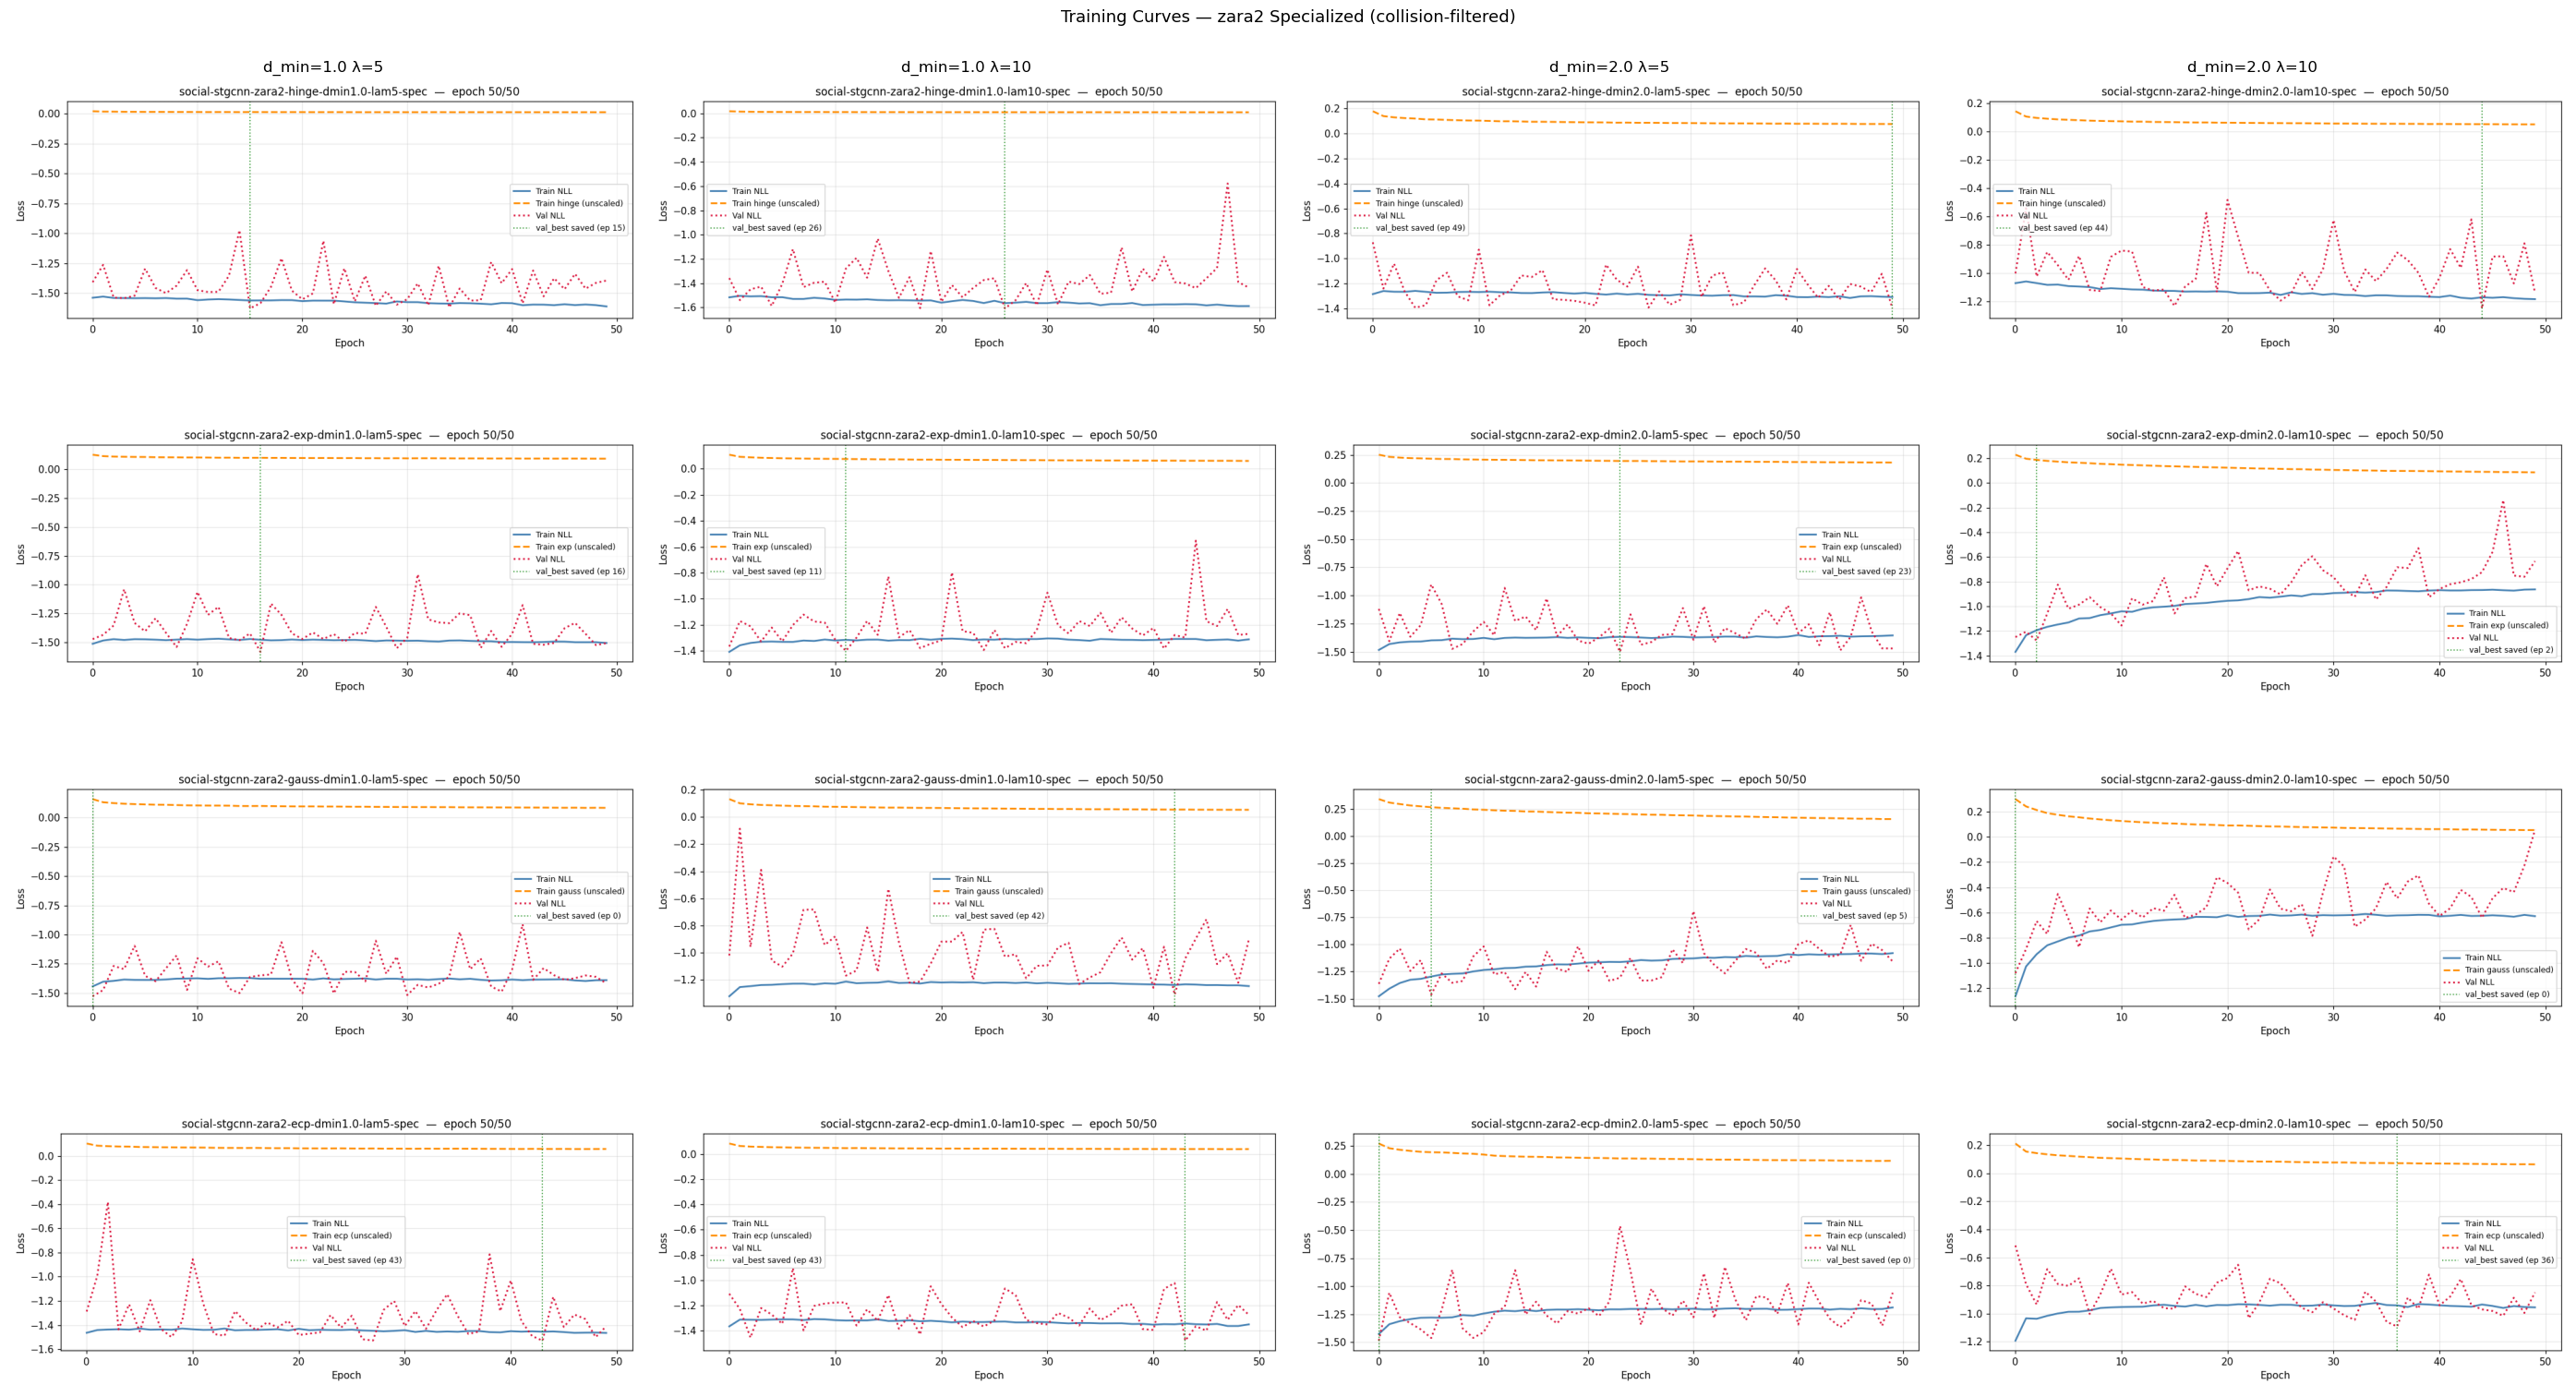

Saved ./finetune_specialized2_zara2\specialized_training_curves.png


In [13]:
from matplotlib.image import imread

n_rows = len(LOSS_FN_LIST)
n_cols = len(D_MIN_LIST) * len(LAMBDA_LIST)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows), squeeze=False)

for row_i, loss in enumerate(LOSS_FN_LIST):
    col_i = 0
    for d_min in D_MIN_LIST:
        for lam in LAMBDA_LIST:
            cfg = {'loss_fn': loss, 'd_min': d_min, 'lambda_col': lam}
            png = os.path.join(run_dir(cfg), 'training_curve.png')
            ax  = axes[row_i][col_i]
            if os.path.exists(png):
                ax.imshow(imread(png))
                ax.axis('off')
            else:
                ax.text(0.5, 0.5, f'Not found:\n{png}',
                        ha='center', va='center', transform=ax.transAxes, fontsize=8)
                ax.axis('off')
            if row_i == 0:
                ax.set_title(f'd_min={d_min} λ={lam}', fontsize=12, pad=6)
            if col_i == 0:
                ax.set_ylabel(f'{loss}', fontsize=11, labelpad=8)
            col_i += 1

fig.suptitle('Training Curves — zara2 Specialized (collision-filtered)', fontsize=13)
plt.tight_layout()
out_png = os.path.join(FINETUNE_ROOT, 'specialized_training_curves.png')
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print('Saved', out_png)


## 12. Evaluate all checkpoints

For each config we evaluate **two** checkpoints:
- `val_best.pth`    — best NLL epoch
- `epoch_final.pth` — last training epoch


In [14]:
results = []

# ── Baseline ─────────────────────────────────────────────────────────────
print('Evaluating baseline ...')
r = evaluate_model(BASELINE_CKPT)
r.update({'Model': 'Baseline', 'Checkpoint': 'val_best',
          'loss_fn': None, 'd_min': None, 'lambda_col': None})
results.append(r)
print(f'  ADE={r["ADE"]:.4f}  FDE={r["FDE"]:.4f}  '
      f'ColRate_avg={r["ColRate_avg"]:.4f}  ColRate_minADE={r["ColRate_minADE"]:.4f}')

# ── Specialized fine-tuned: both checkpoints ─────────────────────────────
for cfg in CONFIGS:
    for ckpt_file, ckpt_label in [('val_best.pth',    'best NLL'),
                                   ('epoch_final.pth', 'final ep')]:
        path = os.path.join(run_dir(cfg), ckpt_file)
        lbl  = f'{cfg["loss_fn"].upper()} d={cfg["d_min"]} lam={cfg["lambda_col"]} [{ckpt_label}]'
        print(f'Evaluating {lbl} ...')
        r = evaluate_model(path)
        r.update({'Model': lbl, 'Checkpoint': ckpt_label,
                  'loss_fn': cfg['loss_fn'], 'd_min': cfg['d_min'], 'lambda_col': cfg['lambda_col']})
        results.append(r)
        print(f'  ADE={r["ADE"]:.4f}  FDE={r["FDE"]:.4f}  '
              f'ColRate_avg={r["ColRate_avg"]:.4f}  ColRate_minADE={r["ColRate_minADE"]:.4f}')

df = pd.DataFrame(results).set_index('Model')
for col in ['ADE','FDE','ColRate_avg','ColRate_minADE']:
    df[col] = pd.to_numeric(df[col])

base_ade = df.loc['Baseline', 'ADE']
base_fde = df.loc['Baseline', 'FDE']
base_col = df.loc['Baseline', 'ColRate_avg']
df['ΔADE']     = df['ADE']          - base_ade
df['ΔFDE']     = df['FDE']          - base_fde
df['ΔColRate']  = df['ColRate_avg'] - base_col

print('\nDone.')


Evaluating baseline ...
  ADE=0.3048  FDE=0.4967  ColRate_avg=0.4319  ColRate_minADE=0.4072
Evaluating HINGE d=1.0 lam=5 [best NLL] ...
  ADE=0.3034  FDE=0.4981  ColRate_avg=0.4268  ColRate_minADE=0.3898
Evaluating HINGE d=1.0 lam=5 [final ep] ...
  ADE=0.3188  FDE=0.4980  ColRate_avg=0.4276  ColRate_minADE=0.4039
Evaluating HINGE d=1.0 lam=10 [best NLL] ...
  ADE=0.3273  FDE=0.5604  ColRate_avg=0.4115  ColRate_minADE=0.3659
Evaluating HINGE d=1.0 lam=10 [final ep] ...
  ADE=0.3229  FDE=0.5161  ColRate_avg=0.4181  ColRate_minADE=0.3833
Evaluating HINGE d=2.0 lam=5 [best NLL] ...
  ADE=0.3854  FDE=0.5367  ColRate_avg=0.4122  ColRate_minADE=0.4517
Evaluating HINGE d=2.0 lam=5 [final ep] ...
  ADE=0.3860  FDE=0.5364  ColRate_avg=0.4099  ColRate_minADE=0.4354
Evaluating HINGE d=2.0 lam=10 [best NLL] ...
  ADE=0.4439  FDE=0.5738  ColRate_avg=0.3651  ColRate_minADE=0.4506
Evaluating HINGE d=2.0 lam=10 [final ep] ...
  ADE=0.4812  FDE=0.6056  ColRate_avg=0.3629  ColRate_minADE=0.4484
Evaluati

## 13. Results table


In [15]:
display_cols = ['Checkpoint','ADE','FDE','ColRate_avg','ColRate_minADE','ΔADE','ΔFDE','ΔColRate']
fmt = {'ADE':'{:.4f}','FDE':'{:.4f}',
       'ColRate_avg':'{:.4f}','ColRate_minADE':'{:.4f}',
       'ΔADE':'{:+.4f}','ΔFDE':'{:+.4f}','ΔColRate':'{:+.4f}'}

styled = (df[display_cols]
    .style
    .format(fmt)
    .background_gradient(subset=['ColRate_avg'], cmap='RdYlGn_r')
    .background_gradient(subset=['ADE'],         cmap='RdYlGn_r')
    .set_caption(
        'zara2 test results — val_best vs epoch_final for each config.\n'
        'val_best = best NLL checkpoint; epoch_final = last training epoch.')
)
display(styled)

,Checkpoint,ADE,FDE,ColRate_avg,ColRate_minADE,ΔADE,ΔFDE,ΔColRate
Model,,,,,,,,
Baseline,val_best,0.3048,0.4967,0.4319,0.4072,+0.0000,+0.0000,+0.0000
HINGE d=1.0 lam=5 [best NLL],best NLL,0.3034,0.4981,0.4268,0.3898,-0.0015,+0.0015,-0.0051
HINGE d=1.0 lam=5 [final ep],final ep,0.3188,0.4980,0.4276,0.4039,+0.0140,+0.0014,-0.0043
HINGE d=1.0 lam=10 [best NLL],best NLL,0.3273,0.5604,0.4115,0.3659,+0.0225,+0.0638,-0.0204
HINGE d=1.0 lam=10 [final ep],final ep,0.3229,0.5161,0.4181,0.3833,+0.0180,+0.0195,-0.0137
HINGE d=2.0 lam=5 [best NLL],best NLL,0.3854,0.5367,0.4122,0.4517,+0.0805,+0.0400,-0.0197
HINGE d=2.0 lam=5 [final ep],final ep,0.3860,0.5364,0.4099,0.4354,+0.0812,+0.0398,-0.0219
HINGE d=2.0 lam=10 [best NLL],best NLL,0.4439,0.5738,0.3651,0.4506,+0.1391,+0.0772,-0.0667
HINGE d=2.0 lam=10 [final ep],final ep,0.4812,0.6056,0.3629,0.4484,+0.1764,+0.1089,-0.0690


## 14. Tradeoff plot: Collision Rate vs ADE / FDE

- `val_best` checkpoints: **filled** markers
- `epoch_final` checkpoints: **open** markers
- Arrow shows direction val_best -> epoch_final


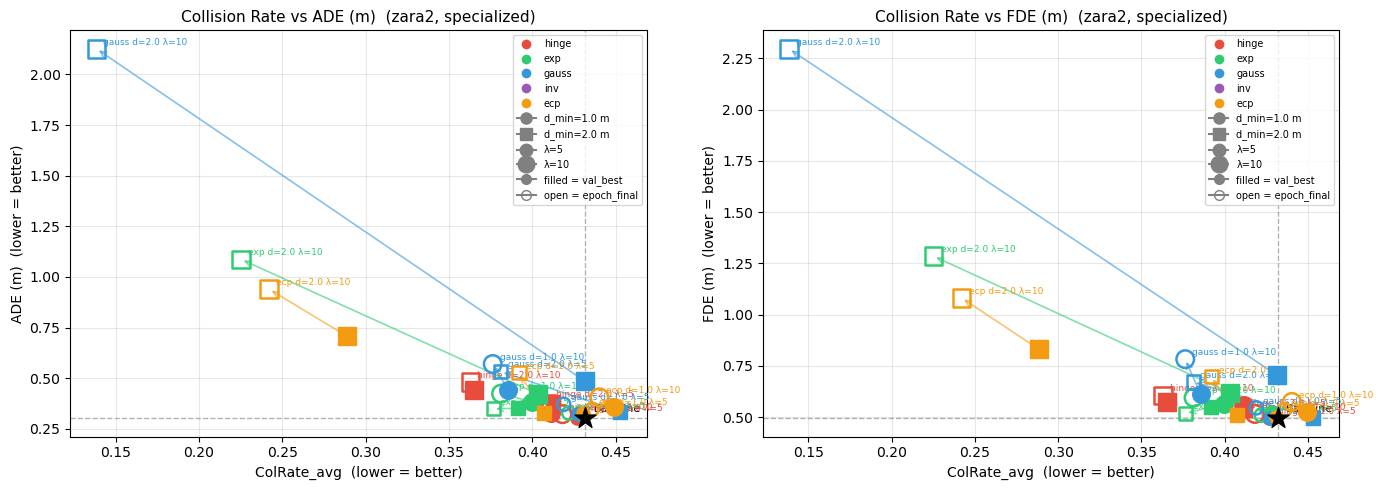

Saved ./finetune_specialized2_zara2\specialized_tradeoff.png


In [16]:
# colour = loss function, marker = d_min, edge_style = lambda
col_map    = {'hinge': '#e74c3c', 'exp': '#2ecc71', 'gauss': '#3498db', 'inv': '#9b59b6', 'ecp': '#f39c12'}
marker_map = {1.0: 'o', 2.0: 's'}
size_map   = {5: 90, 10: 160}   # smaller marker = smaller lambda

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_col, y_lbl in [(axes[0], 'ADE', 'ADE (m)'), (axes[1], 'FDE', 'FDE (m)')]:

    bx = df.loc['Baseline', 'ColRate_avg']
    by = df.loc['Baseline', y_col]
    ax.axvline(bx, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.axhline(by, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.scatter([bx], [by], marker='*', s=250, color='black', zorder=6, label='Baseline')
    ax.annotate('Baseline', (bx, by), xytext=(6, 4), textcoords='offset points', fontsize=8)

    for cfg in CONFIGS:
        c   = col_map[cfg['loss_fn']]
        mk  = marker_map[cfg['d_min']]
        sz  = size_map[cfg['lambda_col']]
        lbl_best  = f'{cfg["loss_fn"].upper()} d={cfg["d_min"]} lam={cfg["lambda_col"]} [best NLL]'
        lbl_final = f'{cfg["loss_fn"].upper()} d={cfg["d_min"]} lam={cfg["lambda_col"]} [final ep]'

        if lbl_best not in df.index or lbl_final not in df.index:
            continue   # skip diverged runs
        rx_best  = df.loc[lbl_best,  'ColRate_avg'];  ry_best  = df.loc[lbl_best,  y_col]
        rx_final = df.loc[lbl_final, 'ColRate_avg'];  ry_final = df.loc[lbl_final, y_col]

        ax.annotate('', xy=(rx_final, ry_final), xytext=(rx_best, ry_best),
                    arrowprops=dict(arrowstyle='->', color=c, lw=1.2, alpha=0.6))
        ax.scatter([rx_best],  [ry_best],  color=c, marker=mk, s=sz, zorder=5)
        ax.scatter([rx_final], [ry_final], facecolors='none', edgecolors=c,
                   marker=mk, s=sz, linewidths=1.8, zorder=5)
        ax.annotate(f'{cfg["loss_fn"]} d={cfg["d_min"]} λ={cfg["lambda_col"]}',
                    (rx_final, ry_final), xytext=(5, 3),
                    textcoords='offset points', fontsize=6.5, color=c)

    ax.set_xlabel('ColRate_avg  (lower = better)', fontsize=10)
    ax.set_ylabel(f'{y_lbl}  (lower = better)', fontsize=10)
    ax.set_title(f'Collision Rate vs {y_lbl}  (zara2, specialized)', fontsize=11)
    ax.grid(True, alpha=0.3)

    legend_els = (
        [Line2D([0],[0], marker='o', color='w', markerfacecolor=v,
                markersize=8, label=k) for k, v in col_map.items()] +
        [Line2D([0],[0], marker=v, color='gray',
                markersize=8, label=f'd_min={k} m') for k, v in marker_map.items()] +
        [Line2D([0],[0], marker='o', color='gray', markersize=int(v**0.5),
                label=f'λ={k}') for k, v in size_map.items()] +
        [Line2D([0],[0], marker='o', color='gray', markersize=7, label='filled = val_best'),
         Line2D([0],[0], marker='o', color='gray', markersize=7,
                fillstyle='none', label='open = epoch_final')]
    )
    ax.legend(handles=legend_els, fontsize=7, loc='upper right')

plt.tight_layout()
out_png = os.path.join(FINETUNE_ROOT, 'specialized_tradeoff.png')
plt.savefig(out_png, dpi=130, bbox_inches='tight')
plt.show()
print('Saved', out_png)


## 15. Summary: best config

Find the config + checkpoint that reduces collision rate the most while keeping DELTA_ADE < +0.05 m.


In [17]:
ADE_BUDGET = 0.05   # max allowed ADE increase over baseline

candidates = df[(df['ΔADE'] <= ADE_BUDGET) & (df.index != 'Baseline')].copy()

if candidates.empty:
    print(f'No config reduces collision rate within ΔADE <= {ADE_BUDGET} m.')
    print('Consider relaxing ADE_BUDGET or reducing SPECIALIZED_EPOCHS.')
else:
    best_cfg = candidates['ΔColRate'].idxmin()
    row = candidates.loc[best_cfg]
    print(f'Best config within ΔADE <= {ADE_BUDGET} m:')
    print(f'  Model       : {best_cfg}')
    print(f'  ADE         : {row["ADE"]:.4f}  (ΔADE={row["ΔADE"]:+.4f})')
    print(f'  FDE         : {row["FDE"]:.4f}  (ΔFDE={row["ΔFDE"]:+.4f})')
    print(f'  ColRate_avg : {row["ColRate_avg"]:.4f}  (ΔColRate={row["ΔColRate"]:+.4f})')
    print(f'  ColRate_minADE: {row["ColRate_minADE"]:.4f}')


Best config within ΔADE <= 0.05 m:
  Model       : EXP d=2.0 lam=5 [final ep]
  ADE         : 0.3493  (ΔADE=+0.0445)
  FDE         : 0.5176  (ΔFDE=+0.0210)
  ColRate_avg : 0.3765  (ΔColRate=-0.0554)
  ColRate_minADE: 0.3779


## 16. Save results & training histories


In [18]:
out_csv = os.path.join(FINETUNE_ROOT, 'specialized_results.csv')
df.to_csv(out_csv)
print('Saved', out_csv)
display(df)


Saved ./finetune_specialized2_zara2\specialized_results.csv


,ADE,FDE,ColRate_avg,ColRate_minADE,Checkpoint,loss_fn,d_min,lambda_col,ΔADE,ΔFDE,ΔColRate
Model,,,,,,,,,,,
Baseline,0.304806,0.496655,0.431868,0.407166,val_best,None,NaN,NaN,0.000000,0.000000,0.000000
HINGE d=1.0 lam=5 [best NLL],0.303355,0.498113,0.426764,0.389794,best NLL,hinge,1.0,5.0,-0.001451,0.001458,-0.005103
HINGE d=1.0 lam=5 [final ep],0.318839,0.498033,0.427579,0.403909,final ep,hinge,1.0,5.0,0.014033,0.001378,-0.004289
HINGE d=1.0 lam=10 [best NLL],0.327311,0.560418,0.411509,0.365907,best NLL,hinge,1.0,10.0,0.022504,0.063763,-0.020358
HINGE d=1.0 lam=10 [final ep],0.322851,0.516147,0.418132,0.383279,final ep,hinge,1.0,10.0,0.018044,0.019492,-0.013735
HINGE d=2.0 lam=5 [best NLL],0.385354,0.536670,0.412161,0.451683,best NLL,hinge,2.0,5.0,0.080548,0.040014,-0.019707
HINGE d=2.0 lam=5 [final ep],0.386050,0.536446,0.409935,0.435396,final ep,hinge,2.0,5.0,0.081243,0.039791,-0.021933
HINGE d=2.0 lam=10 [best NLL],0.443948,0.573832,0.365147,0.450597,best NLL,hinge,2.0,10.0,0.139141,0.077176,-0.066721
HINGE d=2.0 lam=10 [final ep],0.481176,0.605586,0.362866,0.448426,final ep,hinge,2.0,10.0,0.176369,0.108930,-0.069001


In [19]:
out_hist = os.path.join(FINETUNE_ROOT, 'specialized_histories.pkl')
with open(out_hist, 'wb') as f:
    pickle.dump(all_histories, f)
print(f'Saved {len(all_histories)} training histories -> {out_hist}')

# Colab: copy output directory to Drive if needed
# !cp -r {FINETUNE_ROOT} /content/drive/MyDrive/DLproject-Social-STGCNN/


Saved 16 training histories -> ./finetune_specialized2_zara2\specialized_histories.pkl


In [20]:
# Verify all run directories and checkpoints
for cfg in CONFIGS:
    d = run_dir(cfg)
    files = os.listdir(d) if os.path.isdir(d) else ['MISSING']
    print(f'{run_tag(cfg):60s}  {files}')


social-stgcnn-zara2-hinge-dmin1.0-lam5-spec                   ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_curve.png', 'val_best.pth']
social-stgcnn-zara2-hinge-dmin1.0-lam10-spec                  ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_curve.png', 'val_best.pth']
social-stgcnn-zara2-hinge-dmin2.0-lam5-spec                   ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_curve.png', 'val_best.pth']
social-stgcnn-zara2-hinge-dmin2.0-lam10-spec                  ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_curve.png', 'val_best.pth']
social-stgcnn-zara2-exp-dmin1.0-lam5-spec                     ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_curve.png', 'val_best.pth']
social-stgcnn-zara2-exp-dmin1.0-lam10-spec                    ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_cu

In [21]:
print(all_histories)

{'social-stgcnn-zara2-hinge-dmin1.0-lam5-spec': {'train_loss': [-1.4393061593296081, -1.444624208095597, -1.4578960218989268, -1.4661035650387042, -1.4678295217454433, -1.4701331270540632, -1.4713177270884437, -1.4706823943349403, -1.478496992127682, -1.47799625629332, -1.4920007064332808, -1.4887371159847673, -1.4843808108471273, -1.487365946537111, -1.4941448351232016, -1.495607199889373, -1.4968515091795263, -1.497086075142147, -1.4955614252788265, -1.494704706094614, -1.504030174719609, -1.5009425868832968, -1.5008258917709676, -1.5002353984892853, -1.5077423295839045, -1.5151660676167262, -1.5201066095169966, -1.5226033792747715, -1.5267165652135524, -1.50858874031441, -1.5151615924224622, -1.515597040696842, -1.5232032962082847, -1.524827952065119, -1.52725012570135, -1.5247476451038344, -1.5239880889411863, -1.5290540075005312, -1.5323222126599734, -1.52278117871866, -1.5241387819613867, -1.5413520962484484, -1.5363444253438856, -1.5369320440340817, -1.5411962869206095, -1.53370

{'social-stgcnn-zara2-hinge-dmin1.0-lam5-spec': {'train_loss': [-1.4393061593296081, -1.444624208095597, -1.4578960218989268, -1.4661035650387042, -1.4678295217454433, -1.4701331270540632, -1.4713177270884437, -1.4706823943349403, -1.478496992127682, -1.47799625629332, -1.4920007064332808, -1.4887371159847673, -1.4843808108471273, -1.487365946537111, -1.4941448351232016, -1.495607199889373, -1.4968515091795263, -1.497086075142147, -1.4955614252788265, -1.494704706094614, -1.504030174719609, -1.5009425868832968, -1.5008258917709676, -1.5002353984892853, -1.5077423295839045, -1.5151660676167262, -1.5201066095169966, -1.5226033792747715, -1.5267165652135524, -1.50858874031441, -1.5151615924224622, -1.515597040696842, -1.5232032962082847, -1.524827952065119, -1.52725012570135, -1.5247476451038344, -1.5239880889411863, -1.5290540075005312, -1.5323222126599734, -1.52278117871866, -1.5241387819613867, -1.5413520962484484, -1.5363444253438856, -1.5369320440340817, -1.5411962869206095, -1.5337057484965013, -1.542393771068352, -1.5356209635492262, -1.5423639176216553, -1.5515538072440682], 'train_nll': [-1.536425307393074, -1.526905011839983, -1.538353713638172, -1.5393842217641147, -1.5404936173643038, -1.5395912615264333, -1.541133377731331, -1.5392227245540153, -1.544275945400804, -1.5440309156126124, -1.5566989489929464, -1.5512889791431466, -1.548425016364431, -1.5510305660526926, -1.5550384513004039, -1.5595330059286054, -1.558905020477326, -1.558738753320725, -1.5562161216890908, -1.5564298807242052, -1.5649856698464573, -1.5605893866802618, -1.5607524046568366, -1.5609181318583527, -1.567280922357629, -1.5745178045538384, -1.5779952924183713, -1.5813301540002591, -1.5854552228276322, -1.5675051558793076, -1.573083924084175, -1.5733723438125315, -1.5818770810719427, -1.5844334451163686, -1.5854139526685078, -1.5811028737362807, -1.582572055904846, -1.5859964248095828, -1.5911695106424453, -1.5806370445383273, -1.5821634337184876, -1.5989277965533055, -1.5936681620958375, -1.5942026186522429, -1.5986190524285402, -1.5908404989698068, -1.597999160670168, -1.592860135121074, -1.5983210773002812, -1.6089242460524165], 'train_col': [0.01942382809683317, 0.016456163441005155, 0.016091541168507098, 0.0146561308060697, 0.014532818973851882, 0.013891626537467042, 0.013963131766910173, 0.01370806758758982, 0.013155789537191091, 0.013206931903893961, 0.012939651868669542, 0.01251037130785379, 0.0128088405637858, 0.012732929425651011, 0.012178723540391803, 0.012785158669046028, 0.012410698504337654, 0.012330538744667196, 0.012130938884679122, 0.0123450375887058, 0.012191096126722792, 0.011929361444966095, 0.011985299512043565, 0.012136545077693172, 0.01190771629969491, 0.011870347270415528, 0.011577739872935615, 0.011745359572559231, 0.011747728730362604, 0.011783287671396539, 0.011584466195335694, 0.011555058583503634, 0.01173475460808088, 0.011921100210534727, 0.011632763543859507, 0.011271041210805164, 0.011716794951372152, 0.011388486963909603, 0.011769457347785705, 0.011571174627548553, 0.011604930662712825, 0.01151514153386186, 0.011464750216762739, 0.011454117918818644, 0.011484551841650552, 0.01142695172580065, 0.011121076202338062, 0.0114478319860868, 0.01119143037717956, 0.011474087186028985], 'val_loss': [-1.4069154858589172, -1.2618811577558517, -1.5347286760807037, -1.5407464802265167, -1.5192244350910187, -1.2934648990631104, -1.455232858657837, -1.4982890188694, -1.4359474778175354, -1.3057045936584473, -1.473257154226303, -1.48881796002388, -1.4870661199092865, -1.3523990660905838, -0.9734538905322552, -1.6255857944488525, -1.5818836092948914, -1.4463501572608948, -1.2072074264287949, -1.4777140021324158, -1.550012469291687, -1.5001693665981293, -1.0611971020698547, -1.5908131003379822, -1.2909651100635529, -1.5661588311195374, -1.3522435426712036, -1.6043784320354462, -1.4836665093898773, -1.5941836833953857, -1.5485640466213226, -1.4166061580181122, -1.5997124016284943, -1.269635185599327, -1.6171515583992004, -1.4594167470932007, -1.5601683557033539, -1.5573876202106476, -1.238331750035286, -1.4155350029468536, -1.2974186837673187, -1.5833495557308197, -1.309426710009575, -1.5249854922294617, -1.3735701888799667, -1.4653563499450684, -1.3372947573661804, -1.460832267999649, -1.4123297035694122, -1.3929544389247894]}, 'social-stgcnn-zara2-hinge-dmin1.0-lam10-spec': {'train_loss': [-1.34665158330425, -1.365052397052447, -1.3822447267489704, -1.391935295326923, -1.4056248011870114, -1.4076306173593047, -1.4239938878794995, -1.4262345881481482, -1.4136829554799915, -1.4226669461383084, -1.4376770806748693, -1.432342701932279, -1.4376895434972716, -1.4336117293715962, -1.4424626769694855, -1.4431766227372294, -1.4422736464719461, -1.445992331860996, -1.4469615368823694, -1.445946910335281, -1.4669015993916892, -1.4553203806886827, -1.4433436821389005, -1.4542316112939904, -1.4711266518002604, -1.4536800787943165, -1.473539131140806, -1.469531563875394, -1.4633874694506328, -1.4752314817614671, -1.4763195221501637, -1.4645282831497308, -1.4723041169648248, -1.4767265614213012, -1.475246669073415, -1.4901128006659872, -1.4829844990518035, -1.4826685810476783, -1.4778177499528822, -1.4906214336311914, -1.4893558914886742, -1.4855898607491962, -1.487720993544331, -1.485155217470677, -1.487350104785547, -1.4961232009033363, -1.4909648474881319, -1.4984711632738268, -1.5017232890051555, -1.5022913004324687], 'train_nll': [-1.5168728721820242, -1.5050446108831623, -1.5090019644760504, -1.5072473016817396, -1.516321946510939, -1.515891231959913, -1.5301060531197526, -1.5302136089743636, -1.5205458983423081, -1.5267012119293213, -1.5381128959418313, -1.5351352010194848, -1.5358634262186726, -1.5333642696401453, -1.5388678325627878, -1.5411953460273704, -1.540335343802363, -1.5415065387279037, -1.5435225308183733, -1.5423670469260797, -1.5606939456448323, -1.549040475754234, -1.5387672141678934, -1.5468957909360164, -1.564094920165655, -1.5456669153115614, -1.5647827942923802, -1.5608737740695962, -1.5540536293169347, -1.5650716674763983, -1.5649528246584947, -1.5567347515162413, -1.5605276648591204, -1.5676431643769024, -1.5652586535467365, -1.5819430872192228, -1.571994205618777, -1.5714777994567786, -1.5640141357009003, -1.5805029375402908, -1.5776858206202344, -1.574868933093257, -1.5752542514762864, -1.573014759587321, -1.5744798614726803, -1.583358727880125, -1.5769332431680787, -1.5848649723258446, -1.5891325934146479, -1.5888509682523526], 'train_col': [0.017022127732568292, 0.013999219244507869, 0.012675725320179954, 0.01153120164992761, 0.01106971409077173, 0.01082606171660042, 0.010611216781369403, 0.01039790150702825, 0.01068629304371108, 0.010403429171755699, 0.010043580475456377, 0.01027925055009328, 0.009817388518221252, 0.009975255666879419, 0.009640515774367302, 0.009801870717371746, 0.009806170967328021, 0.009551422473618655, 0.009656098295037248, 0.009642013601818674, 0.009379233472140097, 0.009372008205353608, 0.009542353877161697, 0.009266416052435866, 0.009296828057480657, 0.009198684722366856, 0.009124366777600736, 0.009134220493421701, 0.009066617870192247, 0.008984017572024973, 0.008863331209603182, 0.009220648507731475, 0.008822352954326576, 0.009091659054689902, 0.009001197295766929, 0.009183026505709907, 0.008900970322784127, 0.008880920907173956, 0.008619639274808086, 0.008988150585219415, 0.00883299261672286, 0.008927906477706492, 0.008753327179578989, 0.00878595605734414, 0.008712975005429934, 0.008723550783735283, 0.008596838226189792, 0.008639381471567037, 0.008740928951386942, 0.008655965971103604], 'val_loss': [-1.3587041944265366, -1.5400831699371338, -1.4508168995380402, -1.42829167842865, -1.5880637168884277, -1.4050159752368927, -1.1193547323346138, -1.4329646974802017, -1.3964688181877136, -1.3880897909402847, -1.5608753561973572, -1.279308333992958, -1.1915049329400063, -1.355156809091568, -1.0323070995509624, -1.2994734793901443, -1.5212816298007965, -1.3504884093999863, -1.6060447990894318, -1.1354216486215591, -1.55387482047081, -1.415861189365387, -1.5166095495224, -1.4394660890102386, -1.37460258603096, -1.359521523118019, -1.6083150804042816, -1.5409220159053802, -1.3991834968328476, -1.5818484723567963, -1.287896603345871, -1.575638234615326, -1.3867907673120499, -1.4081345796585083, -1.3333079665899277, -1.487889140844345, -1.478119969367981, -1.105197936296463, -1.4689461886882782, -1.280373364686966, -1.3859079778194427, -1.1835867762565613, -1.3911661803722382, -1.4030303359031677, -1.4410825073719025, -1.359900802373886, -1.2751685976982117, -0.5785732194781303, -1.390442669391632, -1.4375965297222137]}, 'social-stgcnn-zara2-hinge-dmin2.0-lam5-spec': {'train_loss': [-0.403280591375606, -0.5723722664884818, -0.627640057817217, -0.6584992655949999, -0.6696676982119102, -0.7093770515260308, -0.7223584388577661, -0.7374976228835971, -0.7458319298114425, -0.7550012309883916, -0.7604811742266481, -0.7702544083197912, -0.7887355620258076, -0.7893172683872918, -0.802370720709017, -0.8151250086551489, -0.8108288272637729, -0.8125497741812422, -0.8256321708245795, -0.8359409297506014, -0.8355000024271566, -0.8453623076626496, -0.8535326902371968, -0.8556629033802554, -0.8596692139557166, -0.861593904017016, -0.8696568187239558, -0.875054428397223, -0.8837132383455601, -0.8748440734406774, -0.8829760709127714, -0.8901641654471556, -0.8958919794522515, -0.8952396938851638, -0.8943146954817597, -0.9054886845424194, -0.9089517931258956, -0.9124239581499913, -0.9072808251940003, -0.9059829408115194, -0.9259251715369927, -0.9241484571103902, -0.9229052098569019, -0.9293270823798438, -0.919967058381831, -0.9362095120225766, -0.9295824803700743, -0.9281191813737847, -0.9319719315845837, -0.936612588028575], 'train_nll': [-1.2837953704387643, -1.2590904634936835, -1.2648093815921813, -1.2655419675243456, -1.2581139765968619, -1.265534564506176, -1.2733693390276082, -1.2721269064864447, -1.2669121770895728, -1.2656581411643546, -1.267383171028869, -1.2646570357010347, -1.2688278009927318, -1.2703538764008255, -1.2751469872025556, -1.2756457927153093, -1.2708091365621073, -1.2682075451106527, -1.2746321537004885, -1.2796073870141378, -1.2742202552829602, -1.2818695586319118, -1.2875776444525682, -1.2796597427638001, -1.2867996715760046, -1.2811941156784694, -1.289928947192754, -1.2920896934792978, -1.2940096204826075, -1.2852921958348549, -1.290552285463773, -1.2941566481608753, -1.296443756698638, -1.2921439062717348, -1.2912648697925169, -1.3023445455487384, -1.3022264018077259, -1.304000706577948, -1.29201770094476, -1.2967408621727035, -1.3073863198821858, -1.3082616321107214, -1.3039844853933467, -1.3076049329120984, -1.3011943349080493, -1.3144833152146302, -1.3018742701284183, -1.3002366856202598, -1.304463505744934, -1.3068240222542784], 'train_col': [0.17610295849686214, 0.1373436366381167, 0.12743386467413384, 0.12140854272283902, 0.11768925927449451, 0.11123150743024293, 0.11020218235144551, 0.10692585624624477, 0.10421604858783558, 0.10213138086923448, 0.1013804004534848, 0.09888052772514003, 0.09601844944124825, 0.09620732072986259, 0.09455525138696959, 0.09210415923780249, 0.0919960647633718, 0.09113155403932513, 0.08979999660983566, 0.0887332900279281, 0.08774405211036981, 0.08730145072376774, 0.0868089915318198, 0.08479936788392853, 0.08542609227597425, 0.08392004372710868, 0.08405442500411164, 0.08340705466427834, 0.08205927549608687, 0.08208962783665043, 0.08151523869975592, 0.08079849900461214, 0.08011035697693511, 0.07938084382087339, 0.07939003452214426, 0.07937117531722368, 0.07865492307920327, 0.07831534896724561, 0.07694737561852058, 0.07815158384844892, 0.07629223303623901, 0.07682263521232115, 0.07621585375217851, 0.07565556855352465, 0.07624545654411925, 0.0756547599236748, 0.07445835795202978, 0.07442350397536228, 0.0744983134141495, 0.07404228585750558], 'val_loss': [-0.870449610054493, -1.2393877804279327, -1.0399677902460098, -1.2622226029634476, -1.392635390162468, -1.371950387954712, -1.1729383021593094, -1.1131868064403534, -1.3013905733823776, -1.3330724835395813, -0.9288711100816727, -1.373228743672371, -1.2937553077936172, -1.2571362107992172, -1.1348995715379715, -1.1467954963445663, -1.092304602265358, -1.3253444731235504, -1.3292371332645416, -1.3372193723917007, -1.3526830971240997, -1.3743823617696762, -1.0484153479337692, -1.168250247836113, -1.2237130403518677, -1.0641214847564697, -1.3915942311286926, -1.2623262703418732, -1.3687411844730377, -1.328575998544693, -0.8149679601192474, -1.3058509826660156, -1.1367094069719315, -1.1090240329504013, -1.3730001151561737, -1.3495830744504929, -1.2099525183439255, -1.0787187367677689, -1.1749024391174316, -1.326270192861557, -1.0834170877933502, -1.2058677524328232, -1.3132711797952652, -1.2181667238473892, -1.3281050473451614, -1.202208325266838, -1.2234975695610046, -1.2675795406103134, -1.1214722841978073, -1.3979834616184235]}, 'social-stgcnn-zara2-hinge-dmin2.0-lam10-spec': {'train_loss': [0.3389877886619679, -0.023802473852338718, -0.13202018709492314, -0.20010878636624463, -0.24682074811222943, -0.2866411670580391, -0.31973672346320264, -0.35293540208376656, -0.3851860873401165, -0.3972288213179324, -0.4130865751022054, -0.4377766677228979, -0.4409860840659271, -0.47004058899343476, -0.4773534738798012, -0.48791937180614287, -0.5054227835679239, -0.5131855659879917, -0.5134432734560597, -0.5244405644173308, -0.5315111585019171, -0.5479787901159405, -0.5565131581857685, -0.560146438896425, -0.5658975657970868, -0.5833937270465748, -0.5711052126085111, -0.5827755541648976, -0.5836424486812695, -0.6005992631233016, -0.6050325410599394, -0.6118709835722003, -0.6160187241296435, -0.6325645585104015, -0.6297446669822977, -0.6302498302371927, -0.6348816469427228, -0.6442333880609782, -0.6440572861957458, -0.6605606446721295, -0.6571917593363643, -0.6520014576209608, -0.6716684948277566, -0.6811111152980679, -0.6751080210530018, -0.6800127402236757, -0.6811679757611696, -0.691159124637759, -0.6986580218455588, -0.7003791772926501], 'train_nll': [-1.0729095414858456, -1.0610961104894794, -1.0726964774057848, -1.0850296226120735, -1.0830545260809188, -1.093755479382221, -1.0969188879280127, -1.1006365178744921, -1.1143478812404382, -1.1090361311916233, -1.112684618132983, -1.1173263129222302, -1.119012825999611, -1.1253100423387778, -1.1271962612405304, -1.1280121604023978, -1.1326678767222766, -1.1316081093147743, -1.1329063862100128, -1.130612659592961, -1.133726439734762, -1.1435807101832804, -1.1438397464826124, -1.1433276994832495, -1.1402362998026285, -1.1561582414794338, -1.137949831841528, -1.149105964762758, -1.143546211280564, -1.154929253713105, -1.1482915047180744, -1.1560504160417142, -1.1570355104383572, -1.16449516370546, -1.158609245838814, -1.158946224827637, -1.1638213420907657, -1.1653401845878408, -1.1655381877523985, -1.1692178221058476, -1.1713366196599118, -1.1608259850578715, -1.1758189360762752, -1.1818287864096404, -1.17273110344053, -1.176222915335219, -1.1718564093286215, -1.1792166892641274, -1.183658330419729, -1.185855856584024], 'train_col': [0.1411897314210646, 0.10372936426726885, 0.09406762883200692, 0.0884920832838199, 0.08362337720919719, 0.08071143003252819, 0.07771821601980532, 0.07477011111052345, 0.0729161806317956, 0.07118073059245944, 0.06995980483714434, 0.06795496401167656, 0.06780267488067002, 0.06552694487392671, 0.0649842777697355, 0.06400927832321257, 0.0627245085869822, 0.06184225488822301, 0.06194631065884533, 0.0606172078996608, 0.06022153013068172, 0.059560191698459, 0.05873265937548275, 0.058318125703119374, 0.057433872999868886, 0.057276450806882144, 0.056684461169580154, 0.056633042066913934, 0.05599037792114902, 0.05543299859862092, 0.05432589741264896, 0.05441794329315655, 0.054101677481518236, 0.05319306129849581, 0.05288645835203487, 0.052869638709654644, 0.0528939711868532, 0.052110681010684536, 0.05214808949146622, 0.0508657174596433, 0.051414485852723193, 0.05088245266571988, 0.05041504520273139, 0.050071766426743464, 0.04976230730887416, 0.04962101825621239, 0.049068843844787095, 0.048805758788416434, 0.048500030366487284, 0.04854766766056996], 'val_loss': [-1.0038437396287918, -0.5439259111881256, -1.0264089107513428, -0.8526694402098656, -0.946210466325283, -1.049395963549614, -0.8811634853482246, -1.1204510629177094, -1.1288145184516907, -0.8873102143406868, -0.8426941260695457, -0.8497372344136238, -1.1003844738006592, -1.1247475743293762, -1.1185350716114044, -1.2339669466018677, -1.0972096771001816, -1.042873427271843, -0.5774617046117783, -1.1366890668869019, -0.48517584800720215, -0.7455461546778679, -0.9996242970228195, -1.00067338347435, -1.1246213167905807, -1.1959224939346313, -1.1469226330518723, -0.9942299276590347, -1.1146638840436935, -0.9744312167167664, -0.6273504085838795, -0.9862306118011475, -1.1351520270109177, -0.9763864502310753, -1.0588629394769669, -0.9730391800403595, -0.8568783636437729, -0.9096972718834877, -0.9997352808713913, -1.1694690734148026, -1.032862089574337, -0.8326926007866859, -0.9654388204216957, -0.6223431527614594, -1.2514610886573792, -0.8852253654040396, -0.8828453123569489, -1.074926882982254, -0.7914822921156883, -1.1418264359235764]}, 'social-stgcnn-zara2-exp-dmin1.0-lam5-spec': {'train_loss': [-0.878585876488104, -0.9107239374784919, -0.9177351398923532, -0.933270146449407, -0.9338360717141532, -0.9373576073506014, -0.9514846215403177, -0.9591684199687911, -0.9565631729982248, -0.9571233957521315, -0.9624810064347779, -0.9604742569409734, -0.9629012173026558, -0.9672642113656048, -0.9786746358968378, -0.9700437923514746, -0.9757478460063779, -0.9848948615353282, -0.9833752428734206, -0.982985814048992, -0.988839944082547, -0.9869700278935394, -0.9872552008042491, -0.992596855795965, -0.9928335063462335, -0.9900265829107626, -1.0013678537272825, -1.0050446714267014, -1.0046657617014598, -1.0017602498135794, -1.0093482347523295, -1.004757317161657, -1.0084332734709833, -1.013746498167757, -1.0064326180675165, -1.0095658113316792, -1.0125042672261475, -1.0160172147358335, -1.0194549101397274, -1.0260776114173051, -1.0243322447669216, -1.0304686371691343, -1.0306603335510425, -1.0269858019986773, -1.027628420511397, -1.0261369373619071, -1.0307106528946055, -1.0331699556814946, -1.0350946970586854, -1.0419880591514634], 'train_nll': [-1.5139471154387405, -1.485214377321848, -1.4736210967951673, -1.4807004646314839, -1.4738101725413548, -1.4748899602308505, -1.4780953475614873, -1.4825932870550853, -1.4777438911965224, -1.473149553001896, -1.4782171715808108, -1.472933810885723, -1.4696785802763652, -1.4753472687509972, -1.4805671171686514, -1.4723443072743532, -1.4789457992324984, -1.4838342434022485, -1.482287500871391, -1.4768090136046332, -1.4817095630294908, -1.4777712569973334, -1.4803514628390955, -1.4829208019787703, -1.4815006784307279, -1.4801703643023483, -1.4845186768145096, -1.490226661812938, -1.4847461316522543, -1.485765456859916, -1.487615803029479, -1.4866133115322488, -1.4911751397620372, -1.493969897853165, -1.4855536664041078, -1.4844240618915092, -1.4885062509239084, -1.49114252517863, -1.4917394320170085, -1.498994001467538, -1.4984014961050778, -1.4997032798402679, -1.5001039517119648, -1.4984722437897349, -1.49437303998606, -1.495042649589903, -1.500123685210701, -1.5002378132648584, -1.499999089696543, -1.5066238801653793], 'train_col': [0.12707224602591458, 0.1148980905158006, 0.11117719167586022, 0.10948606939395754, 0.10799482076549978, 0.10750647268553333, 0.10532214481296487, 0.10468497047034221, 0.10423614345945237, 0.10320523143480949, 0.10314723224250402, 0.10249191497611564, 0.10135547536220856, 0.10161661485785513, 0.10037849545175952, 0.10046010406127548, 0.1006395913948252, 0.09978787650967516, 0.09978245045777744, 0.09876463634938729, 0.09857391932888365, 0.09816024831034303, 0.09861925372293567, 0.09806478723535329, 0.09773343274506127, 0.09802875991123236, 0.09663016538370431, 0.09703639863679807, 0.09601607341016453, 0.09680103953185726, 0.0956535129845748, 0.09637120046569564, 0.09654837214138086, 0.09604468110123483, 0.09582421236588218, 0.09497164716807807, 0.09520039767428203, 0.09502506280333047, 0.09445690626005937, 0.09458327956679391, 0.09481384669528986, 0.09384692729852064, 0.09388872359432583, 0.09429728573877214, 0.09334892367686683, 0.09378114803239884, 0.09388260694402384, 0.0934135717021801, 0.09298087881378285, 0.09292716296329125], 'val_loss': [-1.473249226808548, -1.4360056817531586, -1.3552241176366806, -1.0404281951487064, -1.3329816162586212, -1.405601292848587, -1.291992872953415, -1.4196020662784576, -1.5420452654361725, -1.3409571945667267, -1.0637089312076569, -1.2628729045391083, -1.192959114909172, -1.4633203446865082, -1.482984036207199, -1.423846811056137, -1.5841130912303925, -1.1644392982125282, -1.2622826248407364, -1.4232322573661804, -1.4726138710975647, -1.4151655733585358, -1.472120076417923, -1.430234432220459, -1.4974052608013153, -1.4194459021091461, -1.4266811907291412, -1.1935907155275345, -1.3671800345182419, -1.5523614585399628, -1.4606934189796448, -0.9107482312247157, -1.3019502311944962, -1.3282823115587234, -1.3348405212163925, -1.249554082751274, -1.2655813246965408, -1.5506547689437866, -1.4026791155338287, -1.540202558040619, -1.427238553762436, -1.177968092262745, -1.5143487751483917, -1.5225727260112762, -1.5066152513027191, -1.378469467163086, -1.33235302567482, -1.4270758628845215, -1.5253109335899353, -1.5081033110618591]}, 'social-stgcnn-zara2-exp-dmin1.0-lam10-spec': {'train_loss': [-0.3332669278531055, -0.4424253882976567, -0.4659222145754147, -0.487007730557182, -0.5062183297988845, -0.5282118882893062, -0.5396307916418324, -0.5399497389429952, -0.5551811110803752, -0.5523347026267187, -0.5645839635555338, -0.5682504003246626, -0.5820162300535334, -0.579880677829913, -0.5927209454641594, -0.6057772698804615, -0.599621100336071, -0.6115652844309807, -0.6116179940782911, -0.6152607257046351, -0.6182923004697494, -0.618684407293312, -0.6249229680837655, -0.6404092885190393, -0.6396056276147928, -0.6421660299041891, -0.6427613094570191, -0.6489621050716415, -0.6524250844145209, -0.650023076955865, -0.6547738105906704, -0.660841145408832, -0.6711742130782061, -0.6778339480118054, -0.6794201851012261, -0.6759064815393309, -0.6780595441114127, -0.680761353090042, -0.6906473267126859, -0.6929901411862878, -0.6943407697163946, -0.6917796920591254, -0.6888744302881442, -0.6981418448674485, -0.6965289557488953, -0.7071430671021222, -0.7073647385326828, -0.7016688616779762, -0.7175897811728764, -0.7143024221910694], 'train_nll': [-1.4072266058708593, -1.356736916230946, -1.3385698980674512, -1.3294395709304305, -1.3276873730668208, -1.3302331872708428, -1.3307201204503454, -1.3198663443932688, -1.3233723870016696, -1.312392791112264, -1.3194524894763784, -1.3147181701369401, -1.3189306721333567, -1.3133652677259795, -1.3127689898862103, -1.320571171013805, -1.3166967153670341, -1.3172200175562525, -1.3065356866009836, -1.3139847570318517, -1.3066793121094626, -1.3050044420652274, -1.308878167433952, -1.3167233426820457, -1.3114170780995997, -1.3135909214615822, -1.3068811711741657, -1.3108626707055704, -1.308767037087582, -1.3085041752433388, -1.3038410312397692, -1.3052297173355654, -1.313188607615184, -1.3166047058454373, -1.3214515209561442, -1.308187329853938, -1.310952835330149, -1.3145324731987666, -1.315117015526062, -1.3172928062154026, -1.315499192815486, -1.3125459785020448, -1.3079901946996286, -1.3080914377923902, -1.3080901949992025, -1.317872886129511, -1.3145461123042959, -1.311661909629659, -1.320597182383867, -1.3108403597299645], 'train_col': [0.10739596994646741, 0.09143115420318473, 0.08726476944937575, 0.08424318461050469, 0.08214690509002383, 0.08020213011432652, 0.07910893271427329, 0.07799166252238418, 0.07681912841744781, 0.07600581079600303, 0.07548685311112643, 0.07464677767214797, 0.07369144508478845, 0.07334845813324417, 0.07200480389174044, 0.07147939007244701, 0.07170756164998786, 0.0705654748026433, 0.06949176919850998, 0.0698724026049722, 0.06883870114617777, 0.06863200512328525, 0.06839551919753231, 0.06763140676633977, 0.06718114555465073, 0.06714249052470778, 0.06641198748086648, 0.06619005720320392, 0.06563419524989114, 0.06584810956222255, 0.06490672229433327, 0.06443885700186579, 0.06420143985575656, 0.06387707693464448, 0.0642031342457465, 0.0632280839012739, 0.06328932852749296, 0.06337711369293189, 0.06244696987550554, 0.062430265304685484, 0.06211584206004211, 0.06207662876657536, 0.06191157748945421, 0.060994959570755194, 0.061156124408485564, 0.061072981585104893, 0.06071813769706684, 0.06099930404481001, 0.060300740042353064, 0.05965379670610636], 'val_loss': [-1.365672618150711, -1.1701948195695877, -1.2107148170471191, -1.327545389533043, -1.22003373503685, -1.3255916237831116, -1.201042503118515, -1.1204274520277977, -1.1737169027328491, -1.18230140209198, -1.3151213824748993, -1.3995363116264343, -1.2970452010631561, -1.1692313849925995, -1.2763260900974274, -0.827228918671608, -1.2953335642814636, -1.2395314574241638, -1.3782674372196198, -1.3447333872318268, -1.3187514394521713, -0.7967726364731789, -1.2476863116025925, -1.2607426196336746, -1.3927933424711227, -1.2387908399105072, -1.3794450461864471, -1.3305978775024414, -1.3402075171470642, -1.2406002134084702, -0.9523521214723587, -1.2018881440162659, -1.2657486647367477, -1.1698651015758514, -1.2085840702056885, -1.106602594256401, -1.2606788277626038, -1.1412886455655098, -1.2280043810606003, -1.2812696993350983, -1.2229889780282974, -1.3817709684371948, -1.2779234051704407, -1.2968555092811584, -0.5526791661977768, -1.171323537826538, -1.2084636986255646, -1.0774110406637192, -1.2775256484746933, -1.2681366950273514]}, 'social-stgcnn-zara2-exp-dmin2.0-lam5-spec': {'train_loss': [-0.2311735372095145, -0.27393783273738487, -0.2915128234109675, -0.30771406572456506, -0.31720781043287394, -0.3220435657011446, -0.3325106457973173, -0.3219047167966532, -0.34179099172700284, -0.3458194675198359, -0.3430363301389901, -0.36052536996182544, -0.3511238995390807, -0.35430739202009615, -0.3621416961297739, -0.36852447471992916, -0.3686664955791577, -0.3678037746008052, -0.3761727794889332, -0.37649249577129534, -0.387330262784579, -0.3953366153693014, -0.38880975882327834, -0.3921810463937216, -0.3949414832705213, -0.39762179186755375, -0.41149163338565087, -0.4089117479012456, -0.4065211463517459, -0.4135466579549996, -0.417005667332993, -0.4171979428203993, -0.4203534083541974, -0.42154852682074834, -0.41976225979683934, -0.43078411670849304, -0.4264649669675864, -0.4320569398791291, -0.43514363100939946, -0.4371013751961002, -0.42435126174096915, -0.4409802963220796, -0.4407153928060402, -0.443706040927606, -0.4408820512625136, -0.44896837572256726, -0.45010011273530104, -0.45302712388856464, -0.448351680394984, -0.4491778665272764], 'train_nll': [-1.4843001758405405, -1.4320656428503435, -1.4167942038571189, -1.4103460750838583, -1.4090559873007988, -1.3987980028686597, -1.397134077756904, -1.3837554416106652, -1.3881512190713439, -1.3865850496199703, -1.376962645412531, -1.388640697496806, -1.3774138125338296, -1.3741007472078006, -1.3763780411650506, -1.3754355989454328, -1.3741622978980228, -1.3696882842007534, -1.3768808219668478, -1.3727469047488168, -1.376772673324097, -1.3798860556395478, -1.3703630395637927, -1.3671615920787634, -1.3698181032903434, -1.3737550566709318, -1.3783765258484109, -1.3751366994986238, -1.3655044971279395, -1.3673789110179095, -1.3724035144198772, -1.370618066064609, -1.3687525893337735, -1.3653328553881756, -1.3655715439786282, -1.374515520971875, -1.3634982388610988, -1.3686002466481093, -1.3716904972643815, -1.3659539478578309, -1.3518403546754705, -1.3682212225457495, -1.362797647454711, -1.3614352642912273, -1.358105359844459, -1.3659580150662467, -1.3629718165873557, -1.361468912152819, -1.3588958922051644, -1.3548707274156948], 'train_col': [0.2506253306660079, 0.23162555812980778, 0.2250562789019688, 0.22052640397852474, 0.21836963602767664, 0.21535088965856983, 0.21292469058503477, 0.21237014615258507, 0.2092720440177377, 0.20815311753472618, 0.2067852638474153, 0.20562306533083896, 0.20525798572646092, 0.20395866883990837, 0.20284726514026177, 0.20138222430363412, 0.2010991566980532, 0.2003768992415348, 0.20014160961750171, 0.19925088407616168, 0.19788847999401796, 0.19690988940554996, 0.1963106565495101, 0.19499610963660155, 0.194975327238325, 0.19522665350069834, 0.1933769805342421, 0.19324498903006315, 0.1917966686896691, 0.19076645099594033, 0.1910795707168967, 0.1906840253274801, 0.1896798400128939, 0.18875686588242305, 0.18916185646382874, 0.188746281166727, 0.18740665450576663, 0.18730865964709326, 0.18730937402204487, 0.18577051578566087, 0.1854978179227012, 0.18544818562015083, 0.18441645346235397, 0.18354584442003985, 0.18344466269824855, 0.1833979283322313, 0.18257433758658725, 0.18168835683415333, 0.18210884136718142, 0.18113857286065355], 'val_loss': [-1.1199620813131332, -1.4060654938220978, -1.155009999871254, -1.3666164875030518, -1.2633313685655594, -0.9016686864197254, -1.0768053755164146, -1.4745180904865265, -1.4310457110404968, -1.3200783282518387, -1.234490230679512, -1.353588655591011, -0.9323554718866944, -1.2268068194389343, -1.1866996139287949, -1.308016523718834, -1.0261921249330044, -1.3629759848117828, -1.257444441318512, -1.400313675403595, -1.4290668070316315, -1.3717187643051147, -1.2948115319013596, -1.5013861060142517, -1.1680690050125122, -1.4376851916313171, -1.4132187068462372, -1.3500850200653076, -1.344034880399704, -1.1121315956115723, -1.3934348821640015, -1.0954345911741257, -1.419096052646637, -1.2902449816465378, -1.3359419703483582, -1.3854701817035675, -1.2093275487422943, -1.1243598908185959, -1.2522456347942352, -1.0876471102237701, -1.336282104253769, -1.2557186931371689, -1.4409654438495636, -1.1492182910442352, -1.4885546565055847, -1.366953283548355, -1.0170682966709137, -1.3197594583034515, -1.4697031080722809, -1.4709265530109406]}, 'social-stgcnn-zara2-exp-dmin2.0-lam10-spec': {'train_loss': [0.9123445283765941, 0.7248127031926961, 0.666767055702995, 0.6164096872242846, 0.5743144696881605, 0.5359949237385462, 0.5338755837360094, 0.4983123897235523, 0.4700249352947224, 0.45802976849467253, 0.4328603751148826, 0.4032782061501991, 0.4006483288871687, 0.3824337508616059, 0.35795031254028165, 0.342608863791061, 0.3354846545776656, 0.31893449094752935, 0.29947702813344873, 0.2907137749788835, 0.27642948708908505, 0.2554771824516067, 0.2457471811898457, 0.2366914481011241, 0.2253768955061371, 0.21399655143997465, 0.2013719089242608, 0.18863320134060327, 0.1768652822843991, 0.16748719152005376, 0.1540894349964783, 0.14521877043844425, 0.13251741988541083, 0.11899937674865242, 0.11231940887983917, 0.10329428383026475, 0.09551166473028734, 0.08877961262483006, 0.08012734441620897, 0.07684822995648828, 0.06674347503847161, 0.052047130269135614, 0.04499893084659364, 0.037058022609630294, 0.027691427401678508, 0.025381382872429928, 0.004108332371873449, 4.726989093677018e-06, -0.002411860813812692, -0.00865559083546779], 'train_nll': [-1.369713822480782, -1.2346884112718493, -1.1936967687666877, -1.1666299877471702, -1.1474351309990698, -1.131222809469977, -1.0991200392329417, -1.0956409517531247, -1.0721824661532575, -1.0578837464671842, -1.0409597718669463, -1.044707015156746, -1.0207228394326313, -1.0085682097909063, -1.0034834651002127, -0.9970644138204728, -0.9822491674517938, -0.9774994270284046, -0.9724923173586527, -0.9633997817949731, -0.9555425293916879, -0.9521904798701059, -0.9417932906816172, -0.925593206991059, -0.9306677786647811, -0.921681767632795, -0.9118636149422142, -0.9185202289995369, -0.9008979653549749, -0.9014559477683186, -0.8931416818337847, -0.8906369938753372, -0.8853882760271545, -0.8893179198683694, -0.884492818612692, -0.871897511646267, -0.8729990193432615, -0.8762466536849275, -0.8786483975443194, -0.8726001445983731, -0.8691850111119507, -0.8719676384745643, -0.871798078103583, -0.8688425331614739, -0.8683032840779124, -0.8654898958959321, -0.8699175906620285, -0.873200227470361, -0.8649973116757333, -0.8633320162924685], 'train_col': [0.22820583938137273, 0.19595011211065358, 0.18604638153152872, 0.1783039666488478, 0.17217496192703644, 0.16672177348545816, 0.16329956292210854, 0.15939533651279386, 0.15422073909435277, 0.15159135086952832, 0.1473820167124387, 0.14479852337823357, 0.14213711699081022, 0.1391001949953132, 0.1361433772601245, 0.13396732786367105, 0.13177338245418646, 0.12964339342776887, 0.12719693687535072, 0.12541135508105045, 0.123197201069069, 0.12076676677363787, 0.11875404572374253, 0.11622846579222484, 0.11560446866102113, 0.11356783182497403, 0.11132355144810538, 0.11071534382266014, 0.10777632552812728, 0.10689431398226194, 0.10472311115419392, 0.10358557590218477, 0.10179057044460792, 0.10083172994470874, 0.0996812236704683, 0.09751918051182473, 0.09685106884485992, 0.09650262627685659, 0.09587757496430373, 0.09494483806626049, 0.09359284932183665, 0.09240147668521764, 0.09167970178374486, 0.09059005558432996, 0.08959947013144576, 0.08908712828185322, 0.08740259268747051, 0.08732049551958493, 0.08625854538074991, 0.08546764202156039], 'val_loss': [-1.2498194128274918, -1.2060394287109375, -1.2775920778512955, -1.0583383589982986, -0.8250226979143918, -1.0198815912008286, -0.9866529405117035, -0.9261352270841599, -1.006273865699768, -1.0572764724493027, -1.1562105268239975, -0.9350021854043007, -0.9867660850286484, -0.9569520950317383, -0.7650836203247309, -1.0586159229278564, -0.9338943585753441, -0.9208881184458733, -0.6571834813803434, -0.8382730856537819, -0.6926597319543362, -0.5518519952893257, -0.8704250752925873, -0.8392497673630714, -0.8577383682131767, -0.9038153439760208, -0.8072555959224701, -0.666395693551749, -0.5944127850234509, -0.7078555412590504, -0.7642611935734749, -0.8668073117733002, -0.9230993837118149, -0.7484774105250835, -0.94510817527771, -0.8435465693473816, -0.6840124651789665, -0.6900795623660088, -0.5287836235947907, -0.9270439147949219, -0.859614372253418, -0.8215147405862808, -0.805186003446579, -0.7794625461101532, -0.7237330377101898, -0.5588306710124016, -0.13981305807828903, -0.7512711957097054, -0.7610484436154366, -0.6343005076050758]}, 'social-stgcnn-zara2-gauss-dmin1.0-lam5-spec': {'train_loss': [-0.6495184270225889, -0.7434353435911784, -0.772436439748702, -0.7880628045375754, -0.806983272476894, -0.8210292984315051, -0.8326587956247291, -0.8315034528088764, -0.8373522121550107, -0.8467013239860535, -0.8501868269792417, -0.8604690921985036, -0.8556917759824575, -0.8600542812449176, -0.8715465014300695, -0.8733344623228398, -0.8765586695777692, -0.8828262565581779, -0.889913099749786, -0.8947994564849187, -0.8966488301966006, -0.9032123626732245, -0.8976320674022039, -0.9064717747089339, -0.9072131068120158, -0.9099809838746621, -0.9063599379506053, -0.9212989688404207, -0.9164632980416461, -0.9206629900064894, -0.9273116895096088, -0.9292532432127775, -0.9324569725772229, -0.9304570723476449, -0.9246403895076213, -0.9378539529757771, -0.9356594015427722, -0.9450454917865071, -0.9529218478658334, -0.9525775083196841, -0.9480186991575288, -0.9555837542908948, -0.9519339418265877, -0.9529896460897554, -0.9558233513337809, -0.9579232087343689, -0.9646382112570895, -0.9771869511502546, -0.9658556469996286, -0.9696164624235495], 'train_nll': [-1.443673339134794, -1.403249088917079, -1.3963420595822296, -1.3847939790022084, -1.3879641607040312, -1.3883647825720349, -1.3883127722798325, -1.384001563659044, -1.377450002705663, -1.376004613754226, -1.374372463097902, -1.3791995095770533, -1.3738323643319006, -1.3740645692403601, -1.371480491587786, -1.372093443160619, -1.3785137177588858, -1.3778335347892792, -1.3780167334205735, -1.3778494087055446, -1.3784098231301802, -1.3850943334703523, -1.3751287852845542, -1.3831286456405631, -1.3802768242795294, -1.3783317250691778, -1.375579852822835, -1.3848431143091946, -1.377916644986083, -1.3780621951673089, -1.3847684757859726, -1.3825847490773937, -1.3869793647673072, -1.38095689813296, -1.3761028890323832, -1.3830311651515768, -1.378573244422432, -1.3873658347420577, -1.392876347723773, -1.3909442866357362, -1.3847764112600467, -1.390248540455733, -1.3856359119337749, -1.3848705869622346, -1.3837325787398873, -1.382699267105843, -1.3924909198914117, -1.3974400068807409, -1.3906737627173826, -1.3901217198832247], 'train_col': [0.15883098314024083, 0.1319627486646357, 0.12478112268859778, 0.11934623479600845, 0.1161961788387318, 0.11346709997794492, 0.1111307943020228, 0.11049962320130288, 0.10801955650946717, 0.10586065785368769, 0.10483712693335624, 0.10374608584414653, 0.10362811627744781, 0.10280205862884356, 0.09998680180604987, 0.09975179716778117, 0.10039101080681251, 0.0990014559460607, 0.09762072819379741, 0.09660999181990822, 0.09635219612249696, 0.09637639644116587, 0.09549934177742742, 0.09533137659072816, 0.09461274296348172, 0.09367014709822227, 0.09384398471291472, 0.09270882626571428, 0.0922906653864718, 0.09147984051425767, 0.09149136048234333, 0.09066630378971255, 0.09090448179607832, 0.09009996499124218, 0.0902924994006753, 0.08903544661929695, 0.08858277017205227, 0.0884640684911633, 0.0879909006757586, 0.08767335677360434, 0.08735154592621375, 0.08693295897446512, 0.08674039310071527, 0.08637618767930483, 0.0855818475521836, 0.08495521156791204, 0.08557054335137874, 0.0840506111309538, 0.08496362435048431, 0.08410105259135002], 'val_loss': [-1.5282499492168427, -1.474528968334198, -1.2684355080127716, -1.2961521744728088, -1.0963501632213593, -1.3530927002429962, -1.3995074927806854, -1.2875514030456543, -1.1791480034589767, -1.473667562007904, -1.202886775135994, -1.2742845714092255, -1.228529691696167, -1.46230086684227, -1.5008401274681091, -1.3625600039958954, -1.3494237810373306, -1.3410192131996155, -1.0651220828294754, -1.38035848736763, -1.5035651922225952, -1.1386822015047073, -1.2449013143777847, -1.5036308467388153, -1.3188864588737488, -1.318844199180603, -1.4005676209926605, -1.052047997713089, -1.335349589586258, -1.1886180341243744, -1.5178468227386475, -1.4301845729351044, -1.453316479921341, -1.4202318489551544, -1.3611713647842407, -0.9775159955024719, -1.296949878334999, -1.204107716679573, -1.4444935321807861, -1.488249659538269, -1.298196479678154, -0.9124049469828606, -1.3876145780086517, -1.2871622741222382, -1.347849041223526, -1.3874146044254303, -1.3729365915060043, -1.3497921824455261, -1.3620415031909943, -1.418738692998886]}, 'social-stgcnn-zara2-gauss-dmin1.0-lam10-spec': {'train_loss': [-0.006658053979641054, -0.24626184987828015, -0.31419275037762595, -0.35100062975917407, -0.3729527566612251, -0.3975953653273059, -0.4153418778479705, -0.4308439590400312, -0.4507060848115905, -0.4682582905440311, -0.47760859870813727, -0.47092838558118516, -0.49697832990346885, -0.5062265980049847, -0.5207579567180416, -0.522726367371596, -0.5317123637693685, -0.5421093808926218, -0.5590674928351631, -0.5495529101510358, -0.5572509010572259, -0.5676717457732534, -0.5772784772382035, -0.5838906602040539, -0.593973819136135, -0.5967614705242762, -0.604956913345713, -0.61113192092597, -0.6164066737320849, -0.6340646340958471, -0.627253278635624, -0.6425444245096145, -0.6428653002391017, -0.6505933290695757, -0.6552732305495235, -0.6565819835154022, -0.6540106903246747, -0.6654770019638344, -0.6698059843989407, -0.6749799238230155, -0.6854452005004495, -0.6870878865200329, -0.6970786291772757, -0.6852671239918809, -0.6979325196243883, -0.702185189336296, -0.7066277214363823, -0.7104408684057918, -0.7097015182480095, -0.7185637369388487], 'train_nll': [-1.3213125901009009, -1.2533424064153578, -1.2465060943268178, -1.238181399014907, -1.2366165274345293, -1.2318877468143052, -1.2282405718555296, -1.2278917133808136, -1.2341210356936223, -1.2255462602810647, -1.2286385662429702, -1.2129005464475329, -1.2248551029015362, -1.222038667497596, -1.220807695594745, -1.2115549129562648, -1.2230569394381066, -1.2212011826837934, -1.2269653181234996, -1.2164637986116293, -1.2195338233699644, -1.217853123079834, -1.219335834669873, -1.2177886922306163, -1.2243889171054694, -1.2200219944967488, -1.220074939170504, -1.2233408306066582, -1.219640962052636, -1.2257045738823045, -1.2217708035576633, -1.2251648085146416, -1.2298211182762937, -1.2271354790867828, -1.2250486185274474, -1.2255964437878228, -1.2247538618682845, -1.2285206724049114, -1.230497631842528, -1.2324517906560162, -1.2343987435465906, -1.2351670924846718, -1.2380824456733417, -1.2329440491834307, -1.2350665263044156, -1.2386800250023362, -1.2383289417115653, -1.240523949992366, -1.240313940355933, -1.246112311152908], 'train_col': [0.1314654533743737, 0.1007080555219597, 0.09323133419199688, 0.0887180776448875, 0.08636637763460962, 0.08342923774058378, 0.08128987058876007, 0.07970477529513703, 0.07834149476299744, 0.07572879628619043, 0.0751029970427233, 0.07419721650979974, 0.07278767679732792, 0.07158120514491831, 0.07000497412466543, 0.06888285490146619, 0.06913445708796201, 0.0679091804819863, 0.0667897830565831, 0.06669108962026857, 0.06622829350805652, 0.0650181380304985, 0.0642057360732943, 0.06338980421423912, 0.06304150933354366, 0.062326051868362035, 0.06151180238107113, 0.06122089365338225, 0.060323428892628934, 0.05916399402521187, 0.059451751887980034, 0.05826203818849432, 0.058695582820602304, 0.057654215428009026, 0.056977540436314374, 0.05690144601361296, 0.05707431725052193, 0.056304367859204243, 0.05606916483597663, 0.05574718749196064, 0.05489535423419703, 0.05480792011868784, 0.05410038249196136, 0.05476769278340829, 0.05371339933386421, 0.0536494840209077, 0.053170122929311135, 0.053008307492723915, 0.05306124265828147, 0.052754858287233045], 'val_loss': [-1.0206608045846224, -0.08665288612246513, -0.9581178538501263, -0.38957367837429047, -1.057522602379322, -1.1028143018484116, -1.0056626573204994, -0.6839647144079208, -0.6813858896493912, -0.9435731843113899, -0.8792251120321453, -1.1687919944524765, -1.1313621252775192, -0.8139305519871414, -1.141576662659645, -0.5295567065477371, -0.9225532580167055, -1.2215245962142944, -1.2134529203176498, -1.0802543610334396, -0.9187994673848152, -0.9183719828724861, -0.8471389785408974, -1.199190765619278, -0.8299376461654902, -0.8241758197546005, -1.0295422747731209, -1.0112743526697159, -1.188396379351616, -1.0965742692351341, -1.0939514636993408, -0.9620132148265839, -0.926944687962532, -1.231435626745224, -1.1826918721199036, -1.1444471031427383, -1.0026845037937164, -0.8885431289672852, -1.051205962896347, -0.9660402908921242, -1.2588414549827576, -0.9560051709413528, -1.3096247762441635, -1.0425927713513374, -0.89644630625844, -0.7536023631691933, -1.0844095200300217, -1.0043229162693024, -1.2208590656518936, -0.9030469208955765]}, 'social-stgcnn-zara2-gauss-dmin2.0-lam5-spec': {'train_loss': [0.2239841696365859, 0.1361900594865167, 0.11849865559921709, 0.085135173399088, 0.05124119452612345, 0.034508908860558685, 0.02278139962013378, 0.00841630674725355, -0.007312876165144203, -0.021969331385091294, -0.02426846617067507, -0.04215327146383681, -0.05013542818699696, -0.05762517862310705, -0.07283750008936077, -0.0741373710334301, -0.08217533383258553, -0.09198528328953787, -0.10621576701370321, -0.10612616241844587, -0.11799917465379071, -0.12213513649307019, -0.13085469135711358, -0.14453986008442188, -0.14734972349201986, -0.14915134928138682, -0.1667068026699992, -0.16658122961719832, -0.17095404776722886, -0.17507835272555203, -0.18069261531237252, -0.1896570252991, -0.20253473888476228, -0.20313719462227914, -0.2158615483736345, -0.20786850939887438, -0.22607070969980816, -0.23376479580305343, -0.24053626048356988, -0.23714388167673303, -0.2512767527454583, -0.2529752351805683, -0.26599284753838714, -0.2671603508466898, -0.27343897873810097, -0.2818171994168629, -0.2856466119545837, -0.2844842059552207, -0.3059404567750387, -0.2979238127437673], 'train_nll': [-1.4779413263927135, -1.4075525802119757, -1.355775922017042, -1.3253908899518871, -1.3170695825256118, -1.29596858893254, -1.2767710010557212, -1.2708316693703334, -1.2672206613906594, -1.2490662307182485, -1.2350705714188805, -1.2292392484323924, -1.218092645208041, -1.2158571749117024, -1.2046532026788062, -1.2022485477171203, -1.1903439916150516, -1.1835487900778305, -1.1844284260400044, -1.1765196444683297, -1.167441878843215, -1.164238535329815, -1.160534492412279, -1.161712909102902, -1.155835120166226, -1.14345401176071, -1.1489419915475125, -1.145813154157742, -1.13369369067887, -1.130218984775765, -1.128337210253632, -1.1205979128216588, -1.1233851177285807, -1.116267274978549, -1.1182691438715586, -1.1059671165638192, -1.1105860967853272, -1.1078071634667788, -1.1057575341573982, -1.0903014851401942, -1.0979610486894615, -1.0907524339565935, -1.0945447106347528, -1.0919823418985042, -1.0894129913040371, -1.0880034166828607, -1.082824322777663, -1.0834543190954267, -1.088622849001441, -1.0800211210699044], 'train_col': [0.34038510333833305, 0.3087485301662092, 0.2948549192312152, 0.28210521329107674, 0.27366215285173684, 0.2660954996308153, 0.2599104793179174, 0.2558495931962664, 0.2519815574984911, 0.24541938303457211, 0.24216041739943417, 0.2374171949525963, 0.23359144591661388, 0.2316463972882245, 0.22636313956635173, 0.2256222353425137, 0.22163372941661713, 0.21831270175184622, 0.21564253408086392, 0.21407869578765112, 0.20988854277850122, 0.2084206786555375, 0.205935961379157, 0.20343461111476718, 0.20169707966694075, 0.19886053058990213, 0.1964470385646, 0.19584638633324888, 0.1925479298414186, 0.19102812698471916, 0.18952892117144526, 0.18618817695293777, 0.18417007786532244, 0.1826260169903033, 0.18048152074131163, 0.17961972009737132, 0.17690307946962325, 0.17480847074888473, 0.1730442553859695, 0.17063152260154255, 0.16933685851593813, 0.1675554419499497, 0.1657103734711806, 0.16496439822480197, 0.16319480264747097, 0.16123724424157493, 0.1594355434049354, 0.15979402127509662, 0.15653647865392556, 0.15641946285645397], 'val_loss': [-1.36325404047966, -1.1312488913536072, -1.037268951535225, -1.2439966350793839, -1.1445375084877014, -1.4629287719726562, -1.2669376879930496, -1.3535948991775513, -1.3367265164852142, -1.1111976206302643, -1.0182945877313614, -1.2755044847726822, -1.2539646327495575, -1.4122282564640045, -1.2538570016622543, -1.3883665800094604, -1.0667626857757568, -1.223767802119255, -1.252364233136177, -1.0158199071884155, -1.2429496049880981, -1.1453778445720673, -1.3363354057073593, -1.3060065358877182, -1.1228483617305756, -1.3320489078760147, -1.3318370133638382, -1.301013469696045, -1.0437525063753128, -1.171908900141716, -0.692341074347496, -1.0798480659723282, -1.1903644353151321, -1.2662438303232193, -1.1507926881313324, -1.0421634167432785, -1.0777736008167267, -1.2247871458530426, -1.1467750817537308, -1.171219989657402, -0.9971858263015747, -0.9617123752832413, -1.0397987365722656, -1.1141248792409897, -1.094088226556778, -0.8199701681733131, -1.1509544998407364, -0.9929367750883102, -1.0525600016117096, -1.1568074524402618]}, 'social-stgcnn-zara2-gauss-dmin2.0-lam10-spec': {'train_loss': [1.7345763357110726, 1.3918969158747398, 1.2042334800542787, 1.0266798559085344, 0.9276019871927971, 0.8363176964281142, 0.7744872346520424, 0.7108955677858618, 0.648972961907239, 0.6034220047006311, 0.5645761509505354, 0.5187328167606232, 0.48246381781244463, 0.45985881741656814, 0.42172224851426227, 0.40819254124811455, 0.37055546692175456, 0.3552527071460504, 0.33971343255897823, 0.3053906118684961, 0.28755788359242357, 0.2733106927931771, 0.2561985991404269, 0.2321854145663191, 0.21887457106522348, 0.20297150383161944, 0.17904744038805942, 0.16516884943369284, 0.14377243388011013, 0.12972903349833895, 0.11728001718026723, 0.0943677675181119, 0.08628623177434584, 0.08382633680752082, 0.06496023111651804, 0.04274031717705634, 0.03494787939585919, 0.023447828074960514, 0.013261591582450756, -0.00022579045865193817, -0.01022825486842514, -0.0228605209019526, -0.03271395744856938, -0.03719383579238441, -0.0467328345114293, -0.05352572858506857, -0.06759473946407553, -0.07711846062321534, -0.07385877115550891, -0.08376362251276656], 'train_nll': [-1.264290594690761, -1.0275452485553516, -0.9303915477538294, -0.8598559360171474, -0.8291215156168901, -0.7984241749946923, -0.7821731864250907, -0.7499312671811081, -0.7380797883221345, -0.7179493492310361, -0.697104307339173, -0.6940160518757594, -0.6789464377617651, -0.6666247521837553, -0.6595366314024658, -0.6547510206352832, -0.6516207133730253, -0.6341959247870963, -0.6347391541845114, -0.6369999264504096, -0.6200110611700734, -0.6342713838053304, -0.6275960427037505, -0.625939986589112, -0.6160614880220604, -0.6245910510594068, -0.6225847795952199, -0.6162503151468528, -0.6253113521392956, -0.6206305273050485, -0.6224565589150717, -0.6210130842749116, -0.6187957369022129, -0.6117920193301384, -0.6177249877143276, -0.6259353520969549, -0.6222312221115873, -0.6210697208740568, -0.6178844238436499, -0.6186267815588057, -0.6296902672900248, -0.6253780585446561, -0.6186414747390636, -0.6269199810055799, -0.625516550225574, -0.6216956623649412, -0.6257639481693276, -0.632933121318965, -0.6183275158784186, -0.6286263856314873], 'train_col': [0.29988669742678487, 0.24194421661050283, 0.21346250260176586, 0.18865357863521853, 0.17567235048744798, 0.16347418709968528, 0.1556660420254104, 0.14608268426774546, 0.13870527602862134, 0.1321371359418529, 0.12616804630185166, 0.12127488705712233, 0.11614102663746638, 0.11264835614277872, 0.1081258887100185, 0.1062943560681342, 0.1022176187541408, 0.09894486342000869, 0.0974452583870107, 0.0942390543181276, 0.09075689419328827, 0.0907582083352401, 0.08837946399670932, 0.08581253981881941, 0.0834936067469187, 0.08275625566670368, 0.08016322235497393, 0.0781419168988084, 0.07690837914701695, 0.07503595668100571, 0.07397365772215896, 0.07153808506739925, 0.07050819725318011, 0.06956183585489906, 0.06826852230615048, 0.06686756647617896, 0.06571791069984821, 0.06445175496118064, 0.06311460160614216, 0.061840098831340555, 0.0619462013259068, 0.060251753925266424, 0.05859275193264087, 0.0589726141692887, 0.05787837141114034, 0.05681699380827274, 0.05581692081349072, 0.05558146688558771, 0.05444687483254676, 0.05448627632322032], 'val_loss': [-1.0805392265319824, -0.8888258337974548, -0.6678871512413025, -0.7698366194963455, -0.4523773640394211, -0.6502982527017593, -0.8746932074427605, -0.5678690187633038, -0.6772388070821762, -0.5835622660815716, -0.6560771614313126, -0.5859108418226242, -0.638840451836586, -0.565237894654274, -0.5863573625683784, -0.4594058245420456, -0.6427082493901253, -0.6152987591922283, -0.5591607205569744, -0.3198080137372017, -0.3654430089518428, -0.44209709018468857, -0.7335053756833076, -0.6536849737167358, -0.4174046814441681, -0.5691773407161236, -0.5893396697938442, -0.5335683375597, -0.7846932336688042, -0.44111264683306217, -0.15549608692526817, -0.23464086838066578, -0.7119072526693344, -0.655192144215107, -0.5658847615122795, -0.35719589376822114, -0.4870985858142376, -0.35391303105279803, -0.30505829770118, -0.5300328768789768, -0.6272874474525452, -0.5655904822051525, -0.4200068414211273, -0.4763263575732708, -0.6411600410938263, -0.48585880547761917, -0.4050684990361333, -0.4377821423113346, -0.22667876072227955, 0.0564609298016876]}, 'social-stgcnn-zara2-ecp-dmin1.0-lam5-spec': {'train_loss': [-0.9530063174301531, -1.019529137306097, -1.0359607336482382, -1.0466161286079787, -1.0536241577408179, -1.0618097875418702, -1.075062518318494, -1.0792467082903636, -1.0841593835654297, -1.0798414326537915, -1.0877768665673286, -1.096240662825786, -1.10409493090176, -1.0987007282977181, -1.114445737525215, -1.114724865046943, -1.1105513452756695, -1.1161192965095605, -1.1168576532263097, -1.1251846303542454, -1.1194867663751773, -1.132098263235596, -1.130071368280465, -1.132021046387471, -1.1302567167828481, -1.1324084220620674, -1.1426571079991696, -1.1410407575407648, -1.1529663299339088, -1.1492085878441973, -1.1459042950858915, -1.1628708703125394, -1.148592780457764, -1.161074343977905, -1.157712199823643, -1.158335660107252, -1.1550325303664053, -1.1563535918428647, -1.1682696035964701, -1.1706573919552128, -1.1634369854762303, -1.1697970513042395, -1.1623033531676463, -1.1679408778020037, -1.1679426587936355, -1.1702820095347195, -1.1817138040574586, -1.1804357522386846, -1.1785470724590426, -1.1802159422417966], 'train_nll': [-1.4639261235535992, -1.4413343022267024, -1.4370618704857865, -1.4347473405967883, -1.43792314888016, -1.4295530201094906, -1.4382261787730504, -1.4363091414779183, -1.4386602965433424, -1.4291071181859427, -1.4350588127243809, -1.439970449945791, -1.4388320169797757, -1.4290098565501896, -1.443519183290683, -1.4406966693638785, -1.4405252240537627, -1.4376257966325534, -1.4345766399207154, -1.444578140913471, -1.4313426396347644, -1.4425610206960662, -1.439207440473109, -1.4408855091750137, -1.4414912058055642, -1.4381184539174645, -1.4445039959457833, -1.447385531130845, -1.4515314045839194, -1.4481155978349167, -1.4425893699735162, -1.4569794210052587, -1.4481095440261733, -1.4563702561748706, -1.4531768780898273, -1.4557258899861234, -1.4494911078515091, -1.4493854490479803, -1.458214574713048, -1.4603724555392577, -1.4506598939982855, -1.4547062341759844, -1.4518309848579933, -1.4551365544519774, -1.4530168464028739, -1.4578773706424526, -1.4644968897043689, -1.4629406330546713, -1.4621971095722865, -1.4651697556056626], 'train_col': [0.10218396063939464, 0.08436103408959339, 0.0802202281860135, 0.07762624138050024, 0.07685979812527151, 0.07354864217974763, 0.0726327336662093, 0.07141248403283638, 0.07090018396606533, 0.06985313563543273, 0.06945639017711931, 0.06874595926430954, 0.06694741960902645, 0.0660618254659334, 0.06581468768114966, 0.06519435994645081, 0.0659947774535787, 0.06430130007078613, 0.063543803160783, 0.0638787014319039, 0.062371176868162265, 0.062092552583369355, 0.06182721669868967, 0.06177289230650579, 0.06224689938930598, 0.06114200979463635, 0.060369377811931496, 0.06126895621116084, 0.05971301459078866, 0.05978140123642799, 0.05933701357145498, 0.058821712060248464, 0.059903350331237525, 0.05905918135663601, 0.05909293850626403, 0.05947804525570293, 0.058891716187940986, 0.05860637430275783, 0.05798899413314099, 0.05794301398885929, 0.05744458065459096, 0.05698184318446774, 0.0579055268317461, 0.05743914007254672, 0.05701483420202342, 0.05751907044446202, 0.0565566153651694, 0.056500974800286256, 0.05673000905132754, 0.05699076306555662], 'val_loss': [-1.2879440039396286, -0.9922387897968292, -0.38145942240953445, -1.4357420206069946, -1.2282296270132065, -1.4526519179344177, -1.1941357403993607, -1.4319832623004913, -1.4998320639133453, -1.3701601326465607, -0.8549565225839615, -1.2239205241203308, -1.4742358028888702, -1.4881440699100494, -1.2844260782003403, -1.3780550360679626, -1.4432245194911957, -1.3783310949802399, -1.419642150402069, -1.3644881546497345, -1.4825243651866913, -1.4711928069591522, -1.4608401954174042, -1.3174035251140594, -1.4215132594108582, -1.3226562440395355, -1.5175954103469849, -1.5281583666801453, -1.2746261954307556, -1.2011310011148453, -1.4082570374011993, -1.284232497215271, -1.4309476017951965, -1.276699721813202, -1.1451150476932526, -1.326092392206192, -1.4737779796123505, -1.4535378515720367, -0.8148327022790909, -1.285016655921936, -1.0306497067213058, -1.3674854040145874, -1.4902081787586212, -1.5294750332832336, -1.1660577803850174, -1.4161578714847565, -1.3130398392677307, -1.3493176400661469, -1.5000185668468475, -1.4096031486988068]}, 'social-stgcnn-zara2-ecp-dmin1.0-lam10-spec': {'train_loss': [-0.5385558164216638, -0.6802336596013084, -0.7286599973231797, -0.7549676167044214, -0.7749565304900573, -0.7845369806679768, -0.8018508873334745, -0.8147806495852102, -0.8177599002251296, -0.8248988741297063, -0.8413236506465005, -0.8586369920067671, -0.8500872261640502, -0.8589907407881768, -0.8553798861074738, -0.8749313064797865, -0.8810785838016649, -0.8757295816894469, -0.8864758408711693, -0.889176673278576, -0.9001897064045192, -0.9021297260452577, -0.9025162701320842, -0.9110887906233954, -0.9114032924417558, -0.9087829443255091, -0.9099172674785785, -0.9205093949245728, -0.9210465042208268, -0.9247399233584481, -0.9229675679187465, -0.9312137724543975, -0.9383497985640192, -0.9382128717029482, -0.9332391532607437, -0.9412729506327854, -0.9415344147662806, -0.950857533550844, -0.952960748376885, -0.9488419981264486, -0.9618504364800647, -0.9537047561772956, -0.9583400536964579, -0.9527650459752819, -0.9588104613670488, -0.959014802080829, -0.9579006680628148, -0.9809567028792893, -0.9787571885115732, -0.9624257186442856], 'train_nll': [-1.365003103223758, -1.311505244696528, -1.3124420027422712, -1.3141426337443716, -1.3112490771989511, -1.3094891691353263, -1.3097737095947188, -1.315113340269744, -1.3073432947380272, -1.3093766636116717, -1.3159038097393223, -1.3188716356104953, -1.3179597041713513, -1.3178591232716552, -1.3101522994598722, -1.3223131711829483, -1.3212336341782314, -1.3175697382388076, -1.3244068107105853, -1.3209839518961868, -1.3256846717218074, -1.3331435708616808, -1.327123334373885, -1.3310274409690523, -1.330814569279915, -1.3276847535517158, -1.3267334305900869, -1.3340021583546953, -1.3340009519966638, -1.3299265973936252, -1.3321737235154563, -1.3369460460252878, -1.3415215590862724, -1.338285876786321, -1.3385677362633188, -1.3415103897573502, -1.3410365248962146, -1.3406205007094678, -1.3465269033501788, -1.3453738539805258, -1.351686753635484, -1.3476255258045546, -1.3488067957928511, -1.3421326593412617, -1.3481196324394, -1.3500390908097832, -1.3457595030587863, -1.3621076896665543, -1.3620104757629758, -1.3494292296099144], 'train_col': [0.08264473007189307, 0.06312715924700828, 0.05837820055213098, 0.05591750150258706, 0.05362925531789357, 0.052495218593839224, 0.050792282201137726, 0.0500332690090153, 0.04895833840714843, 0.048447779474431664, 0.047458014193528554, 0.04602346643502635, 0.04678724857607508, 0.045886838505786606, 0.045477242913188005, 0.04473818787534502, 0.04401550528298064, 0.04418401593698295, 0.0437930965686323, 0.043180728632184424, 0.04254949638408011, 0.04310138613303623, 0.04246070793246835, 0.04199386702687225, 0.041941127671701155, 0.041890180270316275, 0.04168161693714347, 0.04134927694270495, 0.041295445836489884, 0.04051866698669406, 0.04092061710619648, 0.040573226749836426, 0.040317177028599674, 0.0400073001903247, 0.040532858176270455, 0.04002374555561921, 0.03995021134879955, 0.03897629801431913, 0.03935661660204452, 0.039653184723366444, 0.0389836316803334, 0.03939207748328222, 0.0390466751125679, 0.038936762279278135, 0.03893091707543387, 0.039102428286086496, 0.0387858829491325, 0.03811509788748089, 0.038325329034823954, 0.03870034900236481], 'val_loss': [-1.10695880651474, -1.228410854935646, -1.4540340602397919, -1.2200610935688019, -1.2715314775705338, -1.3450788259506226, -0.9039228409528732, -1.3971055001020432, -1.2034822404384613, -1.1845094859600067, -1.1763190925121307, -1.1757499426603317, -1.3587249219417572, -1.2300611585378647, -1.3216562271118164, -1.117118462920189, -1.3843958377838135, -1.2754609435796738, -1.4295230507850647, -1.0477199479937553, -1.1880961209535599, -1.294457584619522, -1.3707042634487152, -1.3224271684885025, -1.3666787147521973, -1.3183956742286682, -1.0648557543754578, -1.1178974509239197, -1.3143504709005356, -1.3396860659122467, -1.3499690741300583, -1.2586357295513153, -1.2958977669477463, -1.3585712015628815, -1.2239777594804764, -1.3152779191732407, -1.2706279009580612, -1.2012527734041214, -1.190204605460167, -1.3865958452224731, -1.3932527601718903, -1.0682326927781105, -1.0218890011310577, -1.4785698354244232, -1.3641623854637146, -1.3995258510112762, -1.1719795167446136, -1.3137637674808502, -1.1959945112466812, -1.2739169001579285]}, 'social-stgcnn-zara2-ecp-dmin2.0-lam5-spec': {'train_loss': [-0.0726462414040584, -0.19540342609145384, -0.23583580189666084, -0.26812496371278466, -0.29624874757010805, -0.3134162516961264, -0.3239595981589121, -0.3401498292074647, -0.3476140691155149, -0.3660392871834049, -0.3813566041085147, -0.4137733014112757, -0.4235406587867774, -0.44374333093910256, -0.44621856493312256, -0.4594920133781988, -0.45857804568932037, -0.4745970911007057, -0.476675076626761, -0.4822246346824853, -0.4970693534543348, -0.5038860030761061, -0.5042900577072025, -0.5193207359822222, -0.5148248536324547, -0.5218532838851444, -0.5253277829913205, -0.5338498081347739, -0.5400124911016734, -0.5413190671639849, -0.5451809190675732, -0.5618080562630365, -0.5662123124844344, -0.5628049573752769, -0.5608381291692571, -0.5732384002370428, -0.5792919774214889, -0.5844126794804898, -0.5966399661445803, -0.5962664531760438, -0.5939842657178871, -0.5935940890349158, -0.5928446841390096, -0.6086875259760738, -0.6107036147930825, -0.6157046046772207, -0.6129313718325408, -0.6241889391816402, -0.6247545985952597, -0.6036094595757566], 'train_nll': [-1.4263314142707706, -1.3389701138344383, -1.3116071650455163, -1.2935478518637575, -1.2815099845445432, -1.279322817344074, -1.2813394919846408, -1.277554880394492, -1.2577366068843723, -1.2634199700181106, -1.2434939625997876, -1.2278573303375133, -1.2181693740593371, -1.2229363107404043, -1.2129710441411927, -1.2219500869743585, -1.2114422598839267, -1.2085637291387994, -1.2089676494284194, -1.2054037307352983, -1.210170610353004, -1.2146681079915327, -1.2063838327808898, -1.2067186341498248, -1.2028319855300031, -1.2030085656763048, -1.2054014284481374, -1.2028031451411025, -1.2066042673911235, -1.2026209050370742, -1.200872263243032, -1.2070409383538157, -1.2049236759658932, -1.1997159982836523, -1.197160440273294, -1.2030508797182593, -1.2015694836948732, -1.2009699629951818, -1.210668716493041, -1.20981265685355, -1.2046705519621685, -1.1995399156801922, -1.199672061228013, -1.2091370441539342, -1.2018414798748585, -1.205456247105617, -1.1970094032874403, -1.203887148940748, -1.2034353328536647, -1.1897479329229326], 'train_col': [0.27073703845240926, 0.22871333656673745, 0.2151542755652421, 0.20508457707284494, 0.1970522437937731, 0.19318131388475498, 0.1914759798394155, 0.18748101125319683, 0.1820245047006034, 0.17947613902736542, 0.17242747312772644, 0.16281680744718904, 0.15892574471212173, 0.15583859295981337, 0.15335049511965856, 0.15249161079684778, 0.15057284460410245, 0.14679333017489246, 0.14645851298069307, 0.14463582016209992, 0.1426202527269028, 0.14215642153899105, 0.14041875039277843, 0.1374795773867951, 0.13760142727996866, 0.1362310561133538, 0.13601472891520622, 0.13379066664176856, 0.1333183568086504, 0.13226036620940002, 0.13113827246075221, 0.12904657545145745, 0.1277422699788513, 0.1273822083368955, 0.1272644674253845, 0.1259624954211966, 0.12445549980932197, 0.12331145737580089, 0.12280575113818627, 0.1227092416451652, 0.12213725867038665, 0.12118916554997365, 0.12136547276100447, 0.12008990369766026, 0.11822757267126048, 0.11795032736953608, 0.11681560722230248, 0.11593964398301954, 0.11573614475367837, 0.11722769509538893], 'val_loss': [-1.485846072435379, -1.0587426722049713, -1.2769906967878342, -1.3292183130979538, -1.385349065065384, -1.4620383977890015, -1.208799108862877, -0.8536885641515255, -1.3765924721956253, -1.4606733322143555, -1.4103611409664154, -1.2469919621944427, -1.1846231520175934, -0.8577840030193329, -1.2522272318601608, -1.1384837478399277, -1.261728212237358, -1.3317232877016068, -1.222149133682251, -1.2440876513719559, -1.1964398920536041, -1.2667153626680374, -1.1349757760763168, -0.46369918435811996, -0.8631561696529388, -1.344386249780655, -1.0217882320284843, -1.1954231709241867, -1.2623955607414246, -1.1289571076631546, -1.2776886373758316, -0.8844640851020813, -1.2836201190948486, -0.8287168936803937, -1.1192245930433273, -1.303957760334015, -1.0889283120632172, -1.1013176143169403, -1.2471270710229874, -0.9719096124172211, -1.3418715596199036, -0.9698195978999138, -1.1406650692224503, -1.2893048375844955, -1.3657876551151276, -1.2864913940429688, -1.1241565495729446, -1.1559171825647354, -1.352934092283249, -1.0589968413114548]}, 'social-stgcnn-zara2-ecp-dmin2.0-lam10-spec': {'train_loss': [0.9435628334912218, 0.5296516250674577, 0.41287961212355034, 0.3482310845581598, 0.29497084329121337, 0.26776453136473666, 0.21342066707190618, 0.1847051936526631, 0.15742081764710042, 0.1362239232416763, 0.11566154244391955, 0.08569752148446418, 0.06369836517255897, 0.05937524142768956, 0.03276326773009559, 0.017995173385901043, 0.0008120304930146581, -0.016560871370656545, -0.02991548605089964, -0.03262082513335139, -0.0479982375463312, -0.05756166077745977, -0.07139785781271699, -0.08698098837982776, -0.09831623201684435, -0.0969481804198766, -0.1152791164440009, -0.13644829840045566, -0.14340272836762574, -0.14655137226678605, -0.15928874021872533, -0.16088324226439, -0.17760478095837343, -0.18499136025937954, -0.17847563723434312, -0.19562617013620776, -0.21104568480550087, -0.22062657779270364, -0.2184261928579604, -0.22688253671508427, -0.23557166833170626, -0.24463542560909607, -0.25473494484096537, -0.2675160492893106, -0.2567432412458945, -0.2769184671342373, -0.2946903349239697, -0.2933135896690132, -0.29625114628164345, -0.3066058700629907], 'train_nll': [-1.1947711255877864, -1.0346708556478337, -1.0383491308190103, -1.0169851275146469, -1.0002678140073784, -0.9883798428977183, -0.9877721427022949, -0.9780776512253192, -0.9610344760639723, -0.9567917902455774, -0.9541244990834894, -0.952785807957714, -0.9517507448561432, -0.9428889847021232, -0.9379798637688622, -0.9458426916610825, -0.9506386467075163, -0.9389080162080683, -0.949008177388315, -0.9397330818365711, -0.9408895323962666, -0.9343402446644713, -0.9352391389913337, -0.9392212242350098, -0.9445887634227442, -0.9378790323470914, -0.9383261893377748, -0.945594944348631, -0.9440924142913301, -0.936385077041711, -0.9426322249017021, -0.9470653958445372, -0.9459025941197147, -0.9339971423380135, -0.9253912998955379, -0.9400299186276835, -0.9424648387141006, -0.9538644015095955, -0.932996294295141, -0.9361547578212827, -0.941968413105942, -0.9464301653495131, -0.9485326230294945, -0.9518750182879988, -0.9360845712150714, -0.9466119727423025, -0.9608497178369715, -0.9472932390464369, -0.9539841977200767, -0.9565749307011449], 'train_col': [0.21383339656127054, 0.1564322479877823, 0.1451228748530496, 0.13652162179495245, 0.12952386615653486, 0.12561443806517608, 0.12011928136583215, 0.1162782829298183, 0.11184552927725305, 0.1093015731565019, 0.10697860408271122, 0.10384833376291533, 0.1015449120670326, 0.1002264216311425, 0.0970743117500241, 0.09638378702017457, 0.0951450680651369, 0.09223471341524707, 0.09190926907309728, 0.09071122552448696, 0.08928913000407954, 0.08767785798657195, 0.08638412766375167, 0.08522402263398088, 0.0846272538264477, 0.08409308420508638, 0.0823047083239396, 0.08091466559653077, 0.08006896849274057, 0.07898337082836286, 0.07833434964797294, 0.07861821567495317, 0.07682978158614548, 0.07490057770754824, 0.07469156664586807, 0.07444037559131782, 0.07314191474904154, 0.07332378222760548, 0.07145700950126792, 0.07092722210998813, 0.07063967487666496, 0.07017947401302732, 0.06937976774714774, 0.06843589737203198, 0.06793413254231136, 0.06696934952461991, 0.0666159378335804, 0.06539796404323953, 0.06577330552286996, 0.064996906086918], 'val_loss': [-0.5145533382892609, -0.7906375797465444, -0.9361681491136551, -0.6830536462366581, -0.7899497747421265, -0.8030732683837414, -0.7493752911686897, -1.0035519748926163, -0.8649667128920555, -0.6806695610284805, -0.8652629181742668, -0.847644716501236, -0.9298269897699356, -0.9106582254171371, -0.9622288793325424, -0.9663626849651337, -0.8070142269134521, -0.8601570874452591, -0.8833185583353043, -0.7803575992584229, -0.7467247098684311, -0.6523092985153198, -1.033950388431549, -0.9219948649406433, -0.7519984617829323, -0.7843273654580116, -0.8823751360177994, -0.9597146511077881, -0.9913922399282455, -0.9196845442056656, -0.9647426307201385, -1.0127576738595963, -1.0460366010665894, -0.8447936773300171, -0.9154781401157379, -1.0591435879468918, -1.0935458689928055, -0.8862455934286118, -0.9656876176595688, -0.7227341681718826, -0.9424257576465607, -0.8794388025999069, -0.754362665116787, -0.9403361678123474, -0.9712158590555191, -0.9826331585645676, -1.0171968787908554, -0.8879941254854202, -0.996573805809021, -0.8502461463212967]}}